In [1]:
# Import Packages
import os
import re
import sys
import time
import copy
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import boxcox

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.model_selection import RepeatedKFold

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV

from sklearn.feature_selection import VarianceThreshold

from itertools import product

#%load_ext autoreload
#%reload_ext autoreload
#%autoreload 2
#from model_functions import *

%run Model_functions.ipynb

In [2]:
is_stratified_g = False

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')

# Ignore all of the sklearn warnings.
#warnings.filterwarnings('ignore', module='sklearn')

!chmod 644 ~/.local/share/jupyter/history.sqlite
#!rm ~/.local/share/jupyter/history.sqlite

import logging
logging.getLogger("merf").setLevel(logging.WARNING)

chmod: /Users/kosaraju_b/.local/share/jupyter/history.sqlite: No such file or directory


# TEST CODE

In [4]:
class GROUP_INFO():
    def __init__(self,
        near_zero_sites, high_agb_sites,
        near_zero_plots, high_agb_plots,
        groups, cv
    ):
        self.near_zero_sites = near_zero_sites
        self.high_agb_sites = high_agb_sites
        self.near_zero_plots = near_zero_plots
        self.high_agb_plots = high_agb_plots
        self.groups = groups
        self.cv = cv

class BASE:
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_stratified
    ):
        self.y = y_in
        self.features = features
        self.near_zero_sites = group_info.near_zero_sites
        self.high_agb_sites = group_info.high_agb_sites
        self.near_zero_plots = group_info.near_zero_plots
        self.high_agb_plots = group_info.high_agb_plots
        self.groups = group_info.groups
        self.cv = group_info.cv
        self.is_groups = is_groups
        self.is_stratified = is_stratified
        self.results = {}

        assert features
        self.X = X_in[features]

        categorical_cols = get_categorical_cols(self.X)
        if categorical_cols:
            self.X = pd.get_dummies(self.X, columns=categorical_cols, dtype=int)

            
    def evaluate(self, label):
        fold_sites = None

        if self.is_groups:
            fold_sites = self.results.get("fold_sites")

            verdict = evaluate_experiment(
                label=label,
                results=self.results,
                fold_sites=fold_sites,
                near_zero_sites=self.near_zero_sites,
                high_agb_sites=self.high_agb_sites
            )
        else:
            verdict = evaluate_experiment(
                label=label,
                results=self.results,
                fold_sites=None,
                near_zero_sites=self.near_zero_plots,
                high_agb_sites=self.high_agb_plots
            )

        self.results["verdict"] = verdict

In [5]:
class LIN_REG(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        model_type,
        is_groups, group_info,
        is_stratified
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info, is_stratified)

        self.model_type = model_type
    def set_model(self, model_type):
        self.model_type = model_type

    def run(self, label):
        if self.is_groups:
            self.results = linear_reg_groups(self.model_type,
                                             self.X, self.y,
                                             self.cv, self.groups,
                                             label,
                                             is_stratified=self.is_stratified)
        else:
            self.results = linear_reg_regular(self.model_type,
                                              self.X, self.y,
                                              self.cv,
                                              label)

        self.evaluate(label)

In [6]:
class R_FOREST(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_grid, is_stratified
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info, is_stratified)
        self.is_grid = is_grid

    def run(self, label):
        if self.is_groups:
            self.results = randomForest_groups(self.X, self.y,
                                               self.cv, self.groups,
                                               label,
                                               grid=self.is_grid,
                                               display=True,
                                               is_stratified=self.is_stratified)
        else:
            self.results = randomForest_regular(self.X, self.y,
                                                self.cv,
                                                label,
                                                grid=self.is_grid,
                                                display=True)

        self.evaluate(label)

        show_importances(self.results)

In [7]:
class XGBOOST(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_grid, is_stratified
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info, is_stratified)
        self.is_grid = is_grid

    def run(self, label):
        if self.is_groups:
            self.results = xgboost_groups(self.X, self.y,
                                          self.cv, self.groups,
                                          label,
                                          grid=self.is_grid,
                                          display=True,
                                          is_stratified=self.is_stratified)
        else:
            assert True

        self.evaluate(label)
        
        if self.is_groups:
            show_importances(self.results)

In [8]:
class LGBM(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_grid, is_stratified
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info, is_stratified)
        self.is_grid = is_grid

    def run(self, label):
        if self.is_groups:
            self.results = lightgbm_groups(self.X, self.y,
                                          self.cv, self.groups,
                                          label,
                                          grid=self.is_grid,
                                          display=True,
                                          is_stratified=self.is_stratified)
        else:
            assert True

        self.evaluate(label)
        
        if self.is_groups:
            show_importances(self.results)

In [9]:
def lin_experiment(X, y, is_groups, group_info,
                   label, features_list,
                   experiments,
                   is_stratified=False):
    total     = len(features_list) * len(model_list)
    completed = 0

    for (feat_idx, features), (model_type) in product(enumerate(features_list), model_list):
        completed += 1
        print(f"\n[{completed}/{total}]")
        linr = LIN_REG(X, y, features, model_type, is_groups, group_info, is_stratified)
        
        new_label = f"EXPERIMENT-{completed} {label}, Model: {model_type}, Features: {features}"
        linr.run(new_label)
        experiments[new_label] = linr.results
    print(f"\nCompleted: {completed}/{total} experiments")

In [10]:
def rf_experiment(X, y, is_groups, group_info,
                  label, is_grid, features_list,
                  experiments,
                  is_stratified=False):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")
        rf = R_FOREST(X, y, features, is_groups, group_info, is_grid, is_stratified)
        
        new_label = f"EXPERIMENT-{completed} {label}, Features: {features}."
        
        rf.run(new_label)
        experiments[new_label] = rf.results
    
    print(f"\nCompleted: {completed}/{total} experiments")

In [11]:
def xgboost_experiment(X, y, is_groups, group_info,
                       label, is_grid, features_list,
                       experiments,
                       is_stratified=False):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")
        rf = XGBOOST(X, y, features, is_groups, group_info, is_grid, is_stratified)
        
        new_label = f"EXPERIMENT-{completed} {label}, Features: {features}."
        
        rf.run(new_label)
        experiments[new_label] = rf.results
    
    print(f"\nCompleted: {completed}/{total} experiments")

In [12]:
def lgbm_experiment(X, y, is_groups, group_info,
                    label, is_grid, features_list,
                    experiments,
                    is_stratified=False):
    total     = len(features_list)
    completed = 0

    for features in features_list:
        completed += 1
        print(f"\n[{completed}/{total}]")
        rf = LGBM(X, y, features, is_groups, group_info, is_grid, is_stratified)
        
        new_label = f"EXPERIMENT-{completed} {label}, Features: {features}."
        
        rf.run(new_label)
        experiments[new_label] = rf.results
    
    print(f"\nCompleted: {completed}/{total} experiments")

In [36]:
class MERF_MODEL(BASE):
    def __init__(
        self,
        X_in, y_in, features,
        is_groups, group_info,
        is_grid, is_stratified
    ):
        super().__init__(X_in, y_in, features, is_groups, group_info, is_stratified)
        self.is_grid = is_grid

    def run(self, label):
        if self.is_groups:
            self.results = merf_groups(self.X, self.y,
                                       self.cv, self.groups, self.is_grid,
                                       label, display=True,
                                       is_stratified=self.is_stratified)
        else:
            assert True

        self.evaluate(label)
        show_importances(self.results)

In [37]:
def merf_experiment(X, y, is_groups, group_info,
                    label, is_grid, features_list,
                    experiments, is_stratified=False):
    total     = len(features_list)
    completed = 0

    for i, features in enumerate(features_list, 1):
        completed += 1
        print(f"\n[{completed}/{total}]")
        merf = MERF_MODEL(X, y, features, is_groups, group_info, is_grid, is_stratified)
        
        new_label = f"EXPERIMENT-{completed} {label}, Features: {features}."
        
        merf.run(new_label)
        experiments[new_label] = merf.results

    print(f"\nCompleted: {completed}/{total} experiments")

In [15]:
struct_features = ['height']

sentinel_bands  = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2']
sentinel_indices = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE']

top_spectral_1  = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1']
top_spectral_2  = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']

redband_1       = ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']
redband_2       = ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']

ineraction_terms = ['height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']

useful_categorical = []# ['plot_id']

target = 'plant_AGB_kg'

gen_features_list = [struct_features,
                     struct_features + ineraction_terms,
                 
                     sentinel_bands,
                     sentinel_bands + ineraction_terms,
                 
                     sentinel_indices,
                     sentinel_indices + ineraction_terms,
                 
                     sentinel_bands + sentinel_indices,
                     sentinel_bands + sentinel_indices + ineraction_terms,
                 
                     struct_features + sentinel_bands + sentinel_indices,
                     struct_features + sentinel_bands + sentinel_indices + ineraction_terms,

                     top_spectral_1,
                     top_spectral_1 + ineraction_terms,
                 
                     top_spectral_2,
                     top_spectral_2 + ineraction_terms,
                 
                     redband_1,
                     redband_1 + ineraction_terms,
                 
                     redband_2,
                     redband_2 + ineraction_terms
                    ]

model_list = ["regular", "ridge", "lasso", "elasticnet"]

test_cv = 5
#test_cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

# DOWNLOAD SENTINEL-AGB DATA

In [16]:
SENTINEL_DATA_CSV        = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_SENTINEL_CANOPY.csv"
#SENINEL_MISSING_DATA_CSV = "../../DATA/AGB_DATA/Merged_Data/Sentinel_AGB/AGB_VAL_EO_SENTINEL.csv"

sentinel_df = pd.read_csv(SENTINEL_DATA_CSV)
print(sentinel_df.shape)
sentinel_df.columns

(8774, 34)


Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'height', 'species', 'plant_AGB_kg', 'capture_start',
       'capture_end', 'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2',
       'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'simard_height_m', 'tandemx_height_m'],
      dtype='object')

In [17]:
assert len(sentinel_df["simard_height_m"].head())
assert len(sentinel_df["tandemx_height_m"].head())

In [18]:
sentinel_df['dataset'].unique()

array(['ElSalvador', 'Panama-Chirqui_2', 'CostaRica-Nicoya',
       'CostaRica-Sierpe', 'Belige', 'Panama-Chirqui_1',
       'Honduras-Blanca', 'Brazil-Mangue', 'Brazil-Furo_Do_Chato',
       'Brazil-Manguezal', 'Brazil-Maruipe', 'Brazil-AcarauBoca',
       'Brazil-BocaGrande', 'Brazil-Barreto', 'Brazil-Salinas',
       'Brazil-FuroGrande', 'Brazil-Caetano'], dtype=object)

### Select features

In [19]:
non_feature_cols = [
    'plant_AGB_kg',        # Target variable
    'dataset',             # metadata
    'sentinel_time',       # metadata
    'start_date',          # metadata
    'end_date',            # metadata
    'capture_start',       # metadata
    'capture_end',         # metadata
    'latitude',            # coordinate
    'longitude',           # coordinate
    'diameter',            # Allometric
    'height',               # Allometric
    'cloud_threshold_used',
    'start_date'
]

useful_categorical = ['plot_id', 'species']

target = 'plant_AGB_kg'
feature_cols = [c for c in sentinel_df.columns if c not in non_feature_cols]

X_all = sentinel_df[feature_cols]
# Select TANDEMX
X_all = X_all.rename({'tandemx_height_m': 'height'}, axis=1)
X_all = X_all.drop(columns=['simard_height_m'])
y_all = sentinel_df[target]

In [20]:
X_all.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height'],
      dtype='object')

## DATA PREPROCESSING

### Interaction terms

In [21]:
# height × EVI — the most promising. Height captures structural biomass, EVI captures canopy greenness.
# Their product approximates a "green volume" index and may capture the AGB signal better than either alone.
X_all['height_x_EVI'] = X_all['height'] * X_all['EVI']

#height × NIR — NIR reflectance is strongly tied to canopy density.
# Combined with height it approximates canopy biomass density.
X_all['height_x_NIR'] = X_all['height'] * X_all['NIR']

#height × NDRE1 — red-edge is sensitive to chlorophyll content.
# For mangroves, chlorophyll × height is a reasonable proxy for woody biomass.
X_all['height_x_NDRE1'] = X_all['height'] * X_all['NDRE1']

In [22]:
null_rows   = X_all[X_all.isnull().any(axis=1)]
total_nulls = X_all.isnull().sum().sum()

print(f"Total NULL count           : {total_nulls}")
print(f"Rows with at least one NULL: {len(null_rows)}")
print(f"Total rows                 : {len(sentinel_df)}")
print(f"Percentage                 : {len(null_rows)/len(sentinel_df)*100:.1f}%")

# NULL count per column for only the affected rows
null_col_counts = null_rows.isnull().sum().sort_values(ascending=False)
print("\nNULL count per column in affected rows:")
print(null_col_counts[null_col_counts > 0])

Total NULL count           : 0
Rows with at least one NULL: 0
Total rows                 : 8774
Percentage                 : 0.0%

NULL count per column in affected rows:
Series([], dtype: int64)


In [23]:
assert not total_nulls
#sentinel_df = handle_null_data(sentinel_df)
#X = X.dropna()
#print(X.shape)
#X.columns

### Find correlations

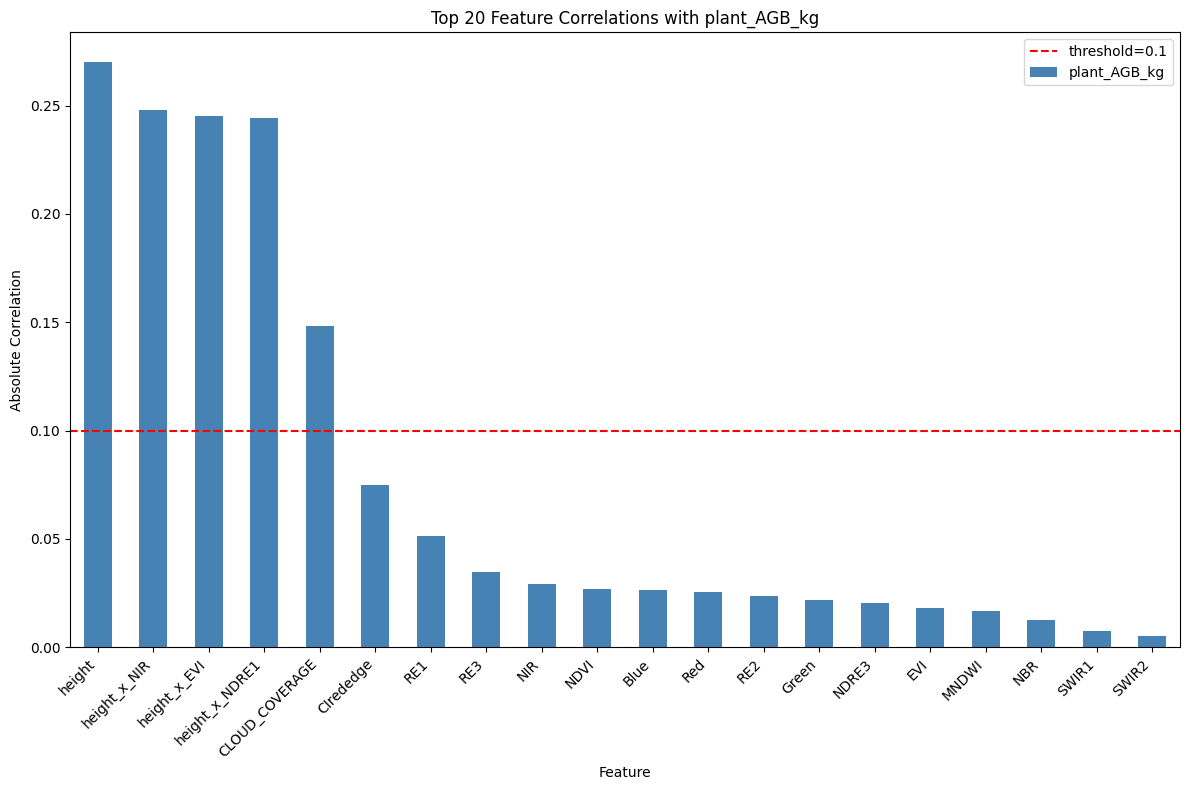

height            0.270332
height_x_NIR      0.247795
height_x_EVI      0.245307
height_x_NDRE1    0.244525
CLOUD_COVERAGE    0.148244
CIrededge         0.075032
RE1               0.051166
RE3               0.034549
NIR               0.029325
NDVI              0.026838
Blue              0.026532
Red               0.025423
RE2               0.023474
Green             0.021944
NDRE3             0.020353
EVI               0.018145
MNDWI             0.016781
NBR               0.012546
SWIR1             0.007646
SWIR2             0.005075
Name: plant_AGB_kg, dtype: float64


In [24]:
numerical_cols = get_numerical_cols(X_all)
target_corr = plot_correlation_matrix(X_all[numerical_cols],
                                      y_all,
                                      top_n=20)
print(target_corr)

**COMMENTS:**  
Columns with a Pearson correlation coefficient (r) between -0.1 and 0.1 with the target variable are generally considered to have a negligible or very weak relationship.

### Remove Low Variance Features (cols)

#### Is variance threshold valid for sentinel-2 data?

- Sentinel-2 surface reflectance values are typically in the range 0.0 to 0.3.  
 - Their absolute variance is naturally small — not because they carry no information but because their scale is small.  
 - A feature with values ranging from 0.05 to 0.25 has variance of ~0.003, which falls below the 0.01 threshold, but the variation within that range is meaningful for AGB prediction.  
 - VarianceThreshold is designed for features with near-identical values across all rows — like a binary column that is always 0.  
 - It is not appropriate for bounded continuous features like reflectance values.

### Remove Features With Weak Correlation to Target

#### Why Pearson correlation is unreliable here?

Pearson correlation measures linear relationship between a feature and the target. 

The above correlation removal process is based on the correlations computed against the original y. But we are going log-transform the target for modeling. 

A feature can have a strong non-linear relationship with AGB that shows up clearly after log transformation but appears weak in linear correlation against raw AGB.  

The experiments (Belige-data-analysis.ipynb) already proved these features are useful.  

### Convert categorical variables to one-hot encoding

# What would actually constitute a good result?
For a model to be trustworthy you would want to see:
 - Grouped CV mean above 0.15
 - Grouped CV std below 0.25
 - No individual grouped CV fold below -0.10
 - Regular CV and grouped CV in the same ballpark — large divergence between them signals leakage
 - Test R² close to grouped CV mean, not far above it
 - Train R² and test R² in the same ballpark — if train R² is much higher than test R², the model is overfitting to the training set even if it passes the other checks. A train R² of 0.55 with a test R² of 0.08 is a red flag regardless of CV scores.
 - RMSE meaningful relative to the AGB range — R² can look acceptable while RMSE is still too large to be useful.    
   If the typical plant weighs 5 kg and RMSE is 16 kg, the model cannot make useful predictions even if R² is positive.   
 - CV fold scores consistent across folds — a high CV mean can hide one very good fold carrying the average.   
   For example, scores of [0.70, 0.40, 0.35, 0.38, 0.42] give a mean of 0.45 which passes your threshold, but that 0.70 is doing all the work.   
   Your std criterion catches some of this but a floor on individual fold scores (similar to your grouped CV fold floor) would make it explicit.

## Threshold for RMSE
There is no universal formula — it depends on what the model output will actually be used for.  

**The most common approach**  
You compute RMSE as a percentage of the mean target value — this is called the Coefficient of Variation of RMSE (CV-RMSE).
cv_rmse = (rmse / y_test.mean()) * 100
print(f"CV-RMSE: {cv_rmse:.1f}%")

A model predicting house prices with RMSE = $50,000 on a mean price of $500,000 is 10% — reasonable.  
The same RMSE on a mean price of $80,000 is 62% — useless.  

For our dataset, if mean AGB is around 10 kg and RMSE is 16 kg, CV-RMSE is 160%.  
That tells you the model's error is larger than the typical value it is trying to predict.

**Determine near_zero_threshold, and high_agb_threshold**  
**near_zero_threshold = 1.0 kg**
 - Any site where the heaviest plant weighs less than 1 kg has near-zero AGB variance.
 - From your data Frenchman Caye (max 0.26 kg) and Shipstern (max 0.94 kg) fall below this.
 - R² is meaningless for these sites as a holdout set.
 - In other words, R² is mathematically unstable when the holdout set has near-zero variance.

**R² is defined as:** 1 - (sum of squared residuals / total sum of squares)
**Total sum of squares is (denominator):** sum of (y - mean(y))²
**Problem:**  
 - When every plant in the holdout site weighs between 0.001 and 0.26 kg, the mean is ~0.03 kg and every value is very close to that mean.
 - This makes the total sum of squares as near-zero.
 - Any prediction error, however small will produce a large negative R² because of the near-zero denominator.

**high_agb_threshold = 100.0 kg**
 - Any site with trees above 100 kg is potentially ecologically distinct from the rest.
 - From your data Channel Caye (max 427 kg) and New River (max 261 kg) fall above this.
 - These are the sites where generalization failure is a genuine concern.

Why I dropped "plot_id"?

What plot_id as a feature was doing
When plot_id was included as a feature, the model learned a lookup table. For each plot it saw during training, it memorised the average AGB for that plot and used that as a prediction signal. This is not generalisation — it is memorisation. A new plot the model has never seen gets no benefit from this signal at all.
The earlier Belize experiments with plot_id (experiments 5-8 in the first run) showed this clearly. Test R² was only 0.036 despite the model having 63 features. The model trained on plot identities that do not exist in the test set.


By dropping plot_id as a feature but keeping it for grouping, you have separated two distinct roles:
Grouping — plot_id tells the CV splitter which plants belong together and must be held out as a unit. This prevents leakage. This is correct.
Features — the model now learns only from spectral measurements, height, and species. These are variables that exist for any new plant at any new location.
This is what makes the model deployable.

# ENTIRE DATASET

In [ ]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups_all = X_all['plot_id'].copy()
X_all = X_all.drop(columns=['plot_id'])

site_groups_all = plot_groups_all.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_all, high_agb_sites_all, near_zero_plots_all, high_agb_plots_all = \
                                get_low_and_high_agb_plots(y_all, plot_groups_all)

grp_all = GROUP_INFO(near_zero_sites_all, high_agb_sites_all,
                     near_zero_plots_all, high_agb_plots_all,
                     groups=plot_groups_all,
                     cv=test_cv)

## ALL DATA. LINEAR REGRESSION

### ALL DATA. Linear regression without groups.

In [24]:
%run Model_functions.ipynb
lin_all_no_groups = {}

lin_experiment(X_all, y_all,
               is_groups=True, group_info=grp_all,
               label="No groups",
               gen_features_list,
               experiments=lin_all_no_groups,
               is_stratified=is_stratified_g)

# 1st-EXPERIMENT: ENTIRE DATA. No groups. Linear regression variants.


[1/72]

 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0138
Test RMSE   : 386.06 kg
Train R² (log scale): 0.2976
Train R² (orig scale): 0.0259
Train RMSE  : 364.28 kg
Num rows    : 7123
Num Features: 1

 Cross-validation ---
CV R² mean: -0.6491
CV R² std : 0.3807
CV scores : [-0.999 -0.997 -0.547 -0.734  0.032]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2625
Grouped CV R² std : 0.1500
Grouped CV scores : [ 0.249  0.272  0.473  0.183  0.245  0.289  0.396 -0.121  0.351  0.289]
 EVALUATION: EXPERIMENT-1 No groups, Model: regular, Features: ['height']

Test set:
  R²   : -0.014
  RMSE : 386.06 kg

Regular CrossValidation:
  Mean   : -0.649
  Std    : 0.381
  Scores : [-0.999 -0.997 -0.547 -0.734  0.032]

  ❌ Test R² is negative (-0.014)
  ❌ CV mean is negative (-0.649)

Grouped CrossValidation:
  El_Jobal_9_4         :   0.249  ✅
  El_Jobal_9_5         :   0.272  ✅
  Bordo_del_Chile_23_6 :   0.473  ✅
  Arco_del_Espino_18_

In [25]:
%run Model_functions.ipynb
tabulate_results(lin_all_no_groups)

,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-70 No groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",28,0.01,381.5,-0.0089,370.7,-1.134,1.068,0.376,0.1144,0.366,none,❌ REJECTED
1,"EXPERIMENT-69 No groups, Model: regular, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",28,0.0151,380.5,-0.0046,369.9,-1.135,1.208,0.3714,0.1219,0.3563,none,❌ REJECTED
2,"EXPERIMENT-38 No groups, Model: ridge, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.0151,386.3,-0.0068,370.3,-0.8582,0.5794,0.3698,0.1541,0.3848,1 (El_Jobal_9_5),❌ REJECTED
3,"EXPERIMENT-37 No groups, Model: regular, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.0179,386.8,-0.0012,369.3,-0.7268,0.4677,0.3635,0.1741,0.3814,1 (El_Jobal_9_5),❌ REJECTED
4,"EXPERIMENT-53 No groups, Model: regular, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",26,0.0031,382.8,-0.0052,370,-1.036,0.6828,0.3625,0.1065,0.3594,none,❌ REJECTED
5,"EXPERIMENT-54 No groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",26,0.0006,383.3,-0.006,370.2,-0.9517,0.6632,0.3584,0.1185,0.3578,none,❌ REJECTED
6,"EXPERIMENT-39 No groups, Model: lasso, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.016,386.5,0.0076,367.7,-0.9002,0.5174,0.3432,0.1115,0.3592,none,❌ REJECTED
7,"EXPERIMENT-46 No groups, Model: ridge, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",8,0.0059,382.3,0.0063,367.9,-0.5647,0.3618,0.3382,0.1022,0.3323,none,❌ REJECTED
8,"EXPERIMENT-45 No groups, Model: regular, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",8,0.0073,382,0.0076,367.7,-0.6311,0.3806,0.3333,0.098,0.3259,none,❌ REJECTED
9,"EXPERIMENT-62 No groups, Model: ridge, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",10,0.0099,381.5,0.006,368,-0.8342,0.3544,0.3324,0.1087,0.3225,none,❌ REJECTED


**Three things stand out**  
**The CV-to-test gap is large and consistent:**
 - Every feature set shows CV R² around 0.25–0.31 but test R² around 0.07–0.09.  That is roughly a 3x to 4x drop.  
 - This strongly suggests plot-level leakage in the regular CV — plants from the same plot appear in both train and test folds, making CV scores artificially optimistic.
 - This is exactly why grouped CV matters for this dataset.

**Adding more features helps CV but not test R²**  
 - Going from height alone (test R² 0.013) to height + all bands + all indices (test R² 0.086) is a real improvement.
 - But adding species on top of the spectral features (experiments 25-28 vs 21-24) actually slightly reduces test R² from 0.081 to 0.078.
 - More features beyond the core spectral set are not helping generalisation.

**Indices alone fail completely (experiments 9-12)**  
 - NDVI, EVI, NDRE and the other indices all have negative test R² despite positive CV means.
 - Raw bands (experiments 5-8) pass with test R² 0.021–0.030.
 - When bands and indices are combined (13-16) test R² improves to 0.039–0.044.
 - This tells you the indices add some value on top of the raw bands but cannot stand alone — the model fitted to indices during CV is learning patterns that do not hold on the test set.

#### COMMENTS.
**Observation 1**
 - Ridge, Lasso, ElasticNet produce identical results to Linear Regression.
 - This means regularization is adding nothing.
 - With only 1 feature there is nothing to regularize.
 - Running all four models on these feature sets is redundant.

**Observation 2 — CV scores are suspiciously uniform**
 - Within each feature group all 5 CV folds score very similarly:
 - Exp 17 (all bands): [0.272 0.261 0.194 0.268 0.263]
 - Exp 29 (top spec) : [0.259 0.274 0.227 0.301 0.295]
 - Standard deviations are 0.026–0.035 across all experiments.
 - This is a hallmark of no-groups CV on this dataset — without plot-level grouping, every fold sees data from every plot, making the model trivially consistent across folds.
 - Cross-validation here is not measuring generalization.

**Observation 3**  
RGB bands fail, NIR+indices fail, combined bands pass  
 - RGB alone         : Test R² -0.036
 - NIR+indices alone : Test R² -0.013
 - Combined          : Test R²  0.022

Linear regression cannot find a signal in RGB or NIR alone but combining them produces a marginally positive test R². This suggests weak multivariate signal that single-band groups cannot express linearly.

**Observation 4**
 - Plot_id dominates wherever it is included
 - Experiments 5-8 and 21-28 all score CV ~0.394-0.395 regardless of whether spectral bands are added or not:  
   **plot + species + height         :** CV 0.394  
   **plot + species + height + bands   :** CV 0.394  
   **plot + species + bands          :** CV 0.394  
 - Adding spectral bands on top of plot_id changes nothing.
 - The model is learning plot identity, not spectral-AGB relationships.
 - This confirms plot_id in features is leaking plot-level information into predictions.

**Conclusion**  
No-groups linear regression is not a trustworthy evaluation for this dataset. 

### ALL DATA. Linear regression with PLOT groups.

In [26]:
%run Model_functions.ipynb

lin_all_plot_groups = {}
lin_experiment(X_all, y_all,
               is_groups=True, group_info=grp_all,
               label="No groups",
               gen_features_list,
               experiments=lin_all_plot_groups,
               is_stratified=is_stratified_g)

# 2nd-EXPERIMENT: ENTIRE DATA. Plot level groups. Linear regression variants.


[1/72]

 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0138
Test RMSE   : 386.06 kg
Train R² (log scale): 0.2976
Train R² (orig scale): 0.0259
Train RMSE  : 364.28 kg
Num rows    : 7123
Num Features: 1

 Cross-validation ---
CV R² mean: -0.6491
CV R² std : 0.3807
CV scores : [-0.999 -0.997 -0.547 -0.734  0.032]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2625
Grouped CV R² std : 0.1500
Grouped CV scores : [ 0.249  0.272  0.473  0.183  0.245  0.289  0.396 -0.121  0.351  0.289]
 EVALUATION: EXPERIMENT-1 No groups, Model: regular, Features: ['height']

Test set:
  R²   : -0.014
  RMSE : 386.06 kg

Regular CrossValidation:
  Mean   : -0.649
  Std    : 0.381
  Scores : [-0.999 -0.997 -0.547 -0.734  0.032]

  ❌ Test R² is negative (-0.014)
  ❌ CV mean is negative (-0.649)

Grouped CrossValidation:
  El_Jobal_9_4         :   0.249  ✅
  El_Jobal_9_5         :   0.272  ✅
  Bordo_del_Chile_23_6 :   0.473  ✅
  Arco_del_Espino_18_

In [27]:
%run Model_functions.ipynb
tabulate_results(lin_all_plot_groups)

,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-70 No groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",28,0.01,381.5,-0.0089,370.7,-1.134,1.068,0.376,0.1144,0.366,none,❌ REJECTED
1,"EXPERIMENT-69 No groups, Model: regular, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",28,0.0151,380.5,-0.0046,369.9,-1.135,1.208,0.3714,0.1219,0.3563,none,❌ REJECTED
2,"EXPERIMENT-38 No groups, Model: ridge, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.0151,386.3,-0.0068,370.3,-0.8582,0.5794,0.3698,0.1541,0.3848,1 (El_Jobal_9_5),❌ REJECTED
3,"EXPERIMENT-37 No groups, Model: regular, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.0179,386.8,-0.0012,369.3,-0.7268,0.4677,0.3635,0.1741,0.3814,1 (El_Jobal_9_5),❌ REJECTED
4,"EXPERIMENT-53 No groups, Model: regular, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",26,0.0031,382.8,-0.0052,370,-1.036,0.6828,0.3625,0.1065,0.3594,none,❌ REJECTED
5,"EXPERIMENT-54 No groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",26,0.0006,383.3,-0.006,370.2,-0.9517,0.6632,0.3584,0.1185,0.3578,none,❌ REJECTED
6,"EXPERIMENT-39 No groups, Model: lasso, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,-0.016,386.5,0.0076,367.7,-0.9002,0.5174,0.3432,0.1115,0.3592,none,❌ REJECTED
7,"EXPERIMENT-46 No groups, Model: ridge, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",8,0.0059,382.3,0.0063,367.9,-0.5647,0.3618,0.3382,0.1022,0.3323,none,❌ REJECTED
8,"EXPERIMENT-45 No groups, Model: regular, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",8,0.0073,382,0.0076,367.7,-0.6311,0.3806,0.3333,0.098,0.3259,none,❌ REJECTED
9,"EXPERIMENT-62 No groups, Model: ridge, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",10,0.0099,381.5,0.006,368,-0.8342,0.3544,0.3324,0.1087,0.3225,none,❌ REJECTED


**Key observations**  
**The CV-test gap check is the strictest criterion here.**   
Experiments 1-4 (height only) pass all other checks but fail on the gap of 0.062-0.078. Experiments 6, 29, 35, 36 similarly fail or go marginal on the gap alone while passing everything else. The 0.05 threshold is doing real discrimination work.

**Experiment 24 remains the cleanest result**   
height + top spectral, ElasticNet: grouped CV 0.246, test R² 0.246, gap 0.000. Three independent signals all pointing at the same number is the strongest trustworthiness signal in the entire set.

**The height + top spectral cluster (21-24)**  
This is the most consistently trustworthy — all four pass, gaps are 0.000 to 0.018, grouped CV and test R² are in tight agreement. Adding species or red-edge bands introduces instability without consistent improvement.

**Indices-only experiments continue to fail badly**  
Experiments 9-12 show grouped CV mean ranging from -0.250 to 0.109, with very high std. Spectral indices alone are not reliable predictors in this dataset regardless of regularisation.

### Linear regression with SITE groups.

0 out of 36 experiments acceptable. Site-level grouping completely destroys linear regression.

Site-level grouping holds out entire sites — all 605 Frenchman Caye rows at once.  

**Linear regression with site-level CV has two compounding problems**
**Problem 1**
 - Frenchman Caye near-zero variance amplifies R² into the thousands negative, polluting the grouped CV mean regardless of how well the model performs on the other 7 sites.

**Problem 2**
 - New River consistently fails as a genuine generalization failure.
 - With only 57 rows across 5 plots, when all of New River is held out the model has to extrapolate to the highest mean AGB site in the dataset.
 - Linear regression cannot do this — it does not have the non-linear flexibility to handle the AGB range jump from ~3 kg (training mean) to ~43 kg (New River mean).

## ALL DATA. RANDOM FOREST

### ALL DATA. RANDOM FOREST WITHOUT GROUPS

In [28]:
%run Model_functions.ipynb

rf_all_no_grps = {}
rf_experiment(X_all, y_all,
              is_groups=True, group_info=grp_all,
              is_grid = False,
              label="No groups",
              gen_features_list,
              experiments=rf_all_no_grps,
              is_stratified=is_stratified_g)


[1/18]

 RANDOM FOREST: EXPERIMENT-1 No groups, Features: ['height'].
Test R²     : 0.0248
Test RMSE   : 378.63 kg
Train R² (log scale): 0.6350
Train R² (orig scale): 0.0481
Train RMSE  : 360.09 kg
Num rows    : 7123
Num Features: 1

 Cross-validation ---
CV R² mean: -0.6000
CV R² std : 1.0213
CV scores : [-2.584 -0.37  -0.089 -0.29   0.333]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4589
Grouped CV R² std : 0.1453
Grouped CV scores : [0.428 0.52  0.616 0.525 0.58  0.581 0.563 0.342 0.27  0.163]
 EVALUATION: EXPERIMENT-1 No groups, Features: ['height'].

Test set:
  R²   : 0.025
  RMSE : 378.63 kg

Regular CrossValidation:
  Mean   : -0.600
  Std    : 1.021
  Scores : [-2.584 -0.37  -0.089 -0.29   0.333]

  ✅ Test R² is positive (0.025)
  ❌ CV mean is negative (-0.600)

Grouped CrossValidation:
  El_Jobal_9_4         :   0.428  ✅
  El_Jobal_9_5         :   0.520  ✅
  Bordo_del_Chile_23_6 :   0.616  ✅
  Arco_del_Espino_18_6 :   0.525  ✅
  El_Jobal_9_1         :   0.580  ✅
  Ar

In [29]:
tabulate_results(rf_all_no_grps)

,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-6 No groups, Features: ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.0133,380.9,0.0688,356.1,-1.093,1.382,0.5458,0.0956,0.5325,none,❌ REJECTED
1,"EXPERIMENT-8 No groups, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",21,0.0089,381.7,0.0689,356.1,-1.101,1.358,0.5329,0.0961,0.524,none,❌ REJECTED
2,"EXPERIMENT-10 No groups, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",22,0.0093,381.6,0.0689,356.1,-1.077,1.314,0.5326,0.1027,0.5233,none,❌ REJECTED
3,"EXPERIMENT-14 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",26,0.0313,377.4,0.0723,355.5,-0.9606,1.169,0.5228,0.1177,0.4915,none,❌ REJECTED
4,"EXPERIMENT-18 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",28,0.0217,379.2,0.0727,355.4,-0.963,1.161,0.5179,0.1146,0.4962,none,❌ REJECTED
5,"EXPERIMENT-9 No groups, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'].",19,0.0074,382,0.0688,356.2,-1.247,1.375,0.5176,0.0992,0.5102,none,❌ REJECTED
6,"EXPERIMENT-16 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.0136,380.8,0.0682,356.3,-1.048,1.302,0.5169,0.1148,0.5033,none,❌ REJECTED
7,"EXPERIMENT-12 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.029,377.8,0.0686,356.2,-1.094,1.28,0.5155,0.1231,0.4865,none,❌ REJECTED
8,"EXPERIMENT-13 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",23,0.0134,380.8,0.0658,356.7,-1.208,1.135,0.5119,0.1247,0.4984,none,❌ REJECTED
9,"EXPERIMENT-15 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.0074,382,0.0683,356.3,-1.183,1.242,0.5116,0.1215,0.5043,none,❌ REJECTED


### ALL DATA. RANDOM FOREST WITH PLOT GROUPS

In [30]:
%run Model_functions.ipynb

rf_all_grps = {}
rf_experiment(X_all, y_all,
              is_groups=True, group_info=grp_all,
              is_grid = False,
              label="Plot groups",
              gen_features_list,
              experiments=rf_all_grps,
              is_stratified=is_stratified_g)


[1/18]

 RANDOM FOREST: EXPERIMENT-1 Plot groups, Features: ['height'].
Test R²     : 0.0248
Test RMSE   : 378.63 kg
Train R² (log scale): 0.6350
Train R² (orig scale): 0.0481
Train RMSE  : 360.09 kg
Num rows    : 7123
Num Features: 1

 Cross-validation ---
CV R² mean: -0.6000
CV R² std : 1.0213
CV scores : [-2.584 -0.37  -0.089 -0.29   0.333]

Grouped Cross-validation ---
Grouped CV R² mean: 0.4589
Grouped CV R² std : 0.1453
Grouped CV scores : [0.428 0.52  0.616 0.525 0.58  0.581 0.563 0.342 0.27  0.163]
 EVALUATION: EXPERIMENT-1 Plot groups, Features: ['height'].

Test set:
  R²   : 0.025
  RMSE : 378.63 kg

Regular CrossValidation:
  Mean   : -0.600
  Std    : 1.021
  Scores : [-2.584 -0.37  -0.089 -0.29   0.333]

  ✅ Test R² is positive (0.025)
  ❌ CV mean is negative (-0.600)

Grouped CrossValidation:
  El_Jobal_9_4         :   0.428  ✅
  El_Jobal_9_5         :   0.520  ✅
  Bordo_del_Chile_23_6 :   0.616  ✅
  Arco_del_Espino_18_6 :   0.525  ✅
  El_Jobal_9_1         :   0.580  ✅


In [31]:
tabulate_results(rf_all_grps)

,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-6 Plot groups, Features: ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.0133,380.9,0.0688,356.1,-1.093,1.382,0.5458,0.0956,0.5325,none,❌ REJECTED
1,"EXPERIMENT-8 Plot groups, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",21,0.0089,381.7,0.0689,356.1,-1.101,1.358,0.5329,0.0961,0.524,none,❌ REJECTED
2,"EXPERIMENT-10 Plot groups, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",22,0.0093,381.6,0.0689,356.1,-1.077,1.314,0.5326,0.1027,0.5233,none,❌ REJECTED
3,"EXPERIMENT-14 Plot groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",26,0.0313,377.4,0.0723,355.5,-0.9606,1.169,0.5228,0.1177,0.4915,none,❌ REJECTED
4,"EXPERIMENT-18 Plot groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",28,0.0217,379.2,0.0727,355.4,-0.963,1.161,0.5179,0.1146,0.4962,none,❌ REJECTED
5,"EXPERIMENT-9 Plot groups, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'].",19,0.0074,382,0.0688,356.2,-1.247,1.375,0.5176,0.0992,0.5102,none,❌ REJECTED
6,"EXPERIMENT-16 Plot groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.0136,380.8,0.0682,356.3,-1.048,1.302,0.5169,0.1148,0.5033,none,❌ REJECTED
7,"EXPERIMENT-12 Plot groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.029,377.8,0.0686,356.2,-1.094,1.28,0.5155,0.1231,0.4865,none,❌ REJECTED
8,"EXPERIMENT-13 Plot groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",23,0.0134,380.8,0.0658,356.7,-1.208,1.135,0.5119,0.1247,0.4984,none,❌ REJECTED
9,"EXPERIMENT-15 Plot groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.0074,382,0.0683,356.3,-1.183,1.242,0.5116,0.1215,0.5043,none,❌ REJECTED


### ALL DATA. RANDOM FOREST WITH SITE GROUPS

# REGION LEVEL MODELING

## SEGGREGATE DATA INTO REGIONS

## REGION LEVEL. RANDOM FOREST EXPERIMENTS

## REGION LEVEL. RANDOM FOREST WITHOUT GROUPS

## REGION LEVEL. RANDOM FOREST. PLOT GROUPS

This is the most striking finding. The grouped CV is excellent (0.699–0.763 for height-containing experiments), every fold is positive, and all checks pass — except the CV-test gap, which runs 0.193–0.317 across all experiments. The model generalises well to new plots within the same sites it trained on, but the test set contains plots from sites that are structurally different enough to hurt performance. This is a site-level generalisation problem, not a model problem. The grouped CV is telling the truth and the test R² is the one being dragged down.

This suggests the train/test split in ElSalvador is inadvertently separating certain site types. Worth checking whether the test set contains a disproportionate share of any particular site or AGB range.

## REGION LEVEL. RANDOM FOREST. SITE GROUPS

# BELIGE DATASET ONLY

In [25]:
belige_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_df['simard_height_m'].head())
assert len(belige_df['tandemx_height_m'].head())

X_belige = belige_df[feature_cols].copy()

# Select TANDEMX
X_belige = X_belige.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige = X_belige.drop(columns=['simard_height_m'])

# Select SIMARD
#X_belige = X_belige.rename({'simard_height_m': 'height'}, axis=1)
#X_belige = X.drop(columns=['tandemx_height_m'])

y_belige  = belige_df[target]

test_cv = 5

In [26]:
X_belige.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height'],
      dtype='object')

## Interaction terms

In [27]:
# height × EVI — the most promising. Height captures structural biomass, EVI captures canopy greenness.
# Their product approximates a "green volume" index and may capture the AGB signal better than either alone.
X_belige['height_x_EVI'] = X_belige['height'] * X_belige['EVI']

#height × NIR — NIR reflectance is strongly tied to canopy density.
# Combined with height it approximates canopy biomass density.
X_belige['height_x_NIR'] = X_belige['height'] * X_belige['NIR']

#height × NDRE1 — red-edge is sensitive to chlorophyll content.
# For mangroves, chlorophyll × height is a reasonable proxy for woody biomass.
X_belige['height_x_NDRE1'] = X_belige['height'] * X_belige['NDRE1']

In [28]:
X_belige.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height',
       'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'],
      dtype='object')

## Show correlations

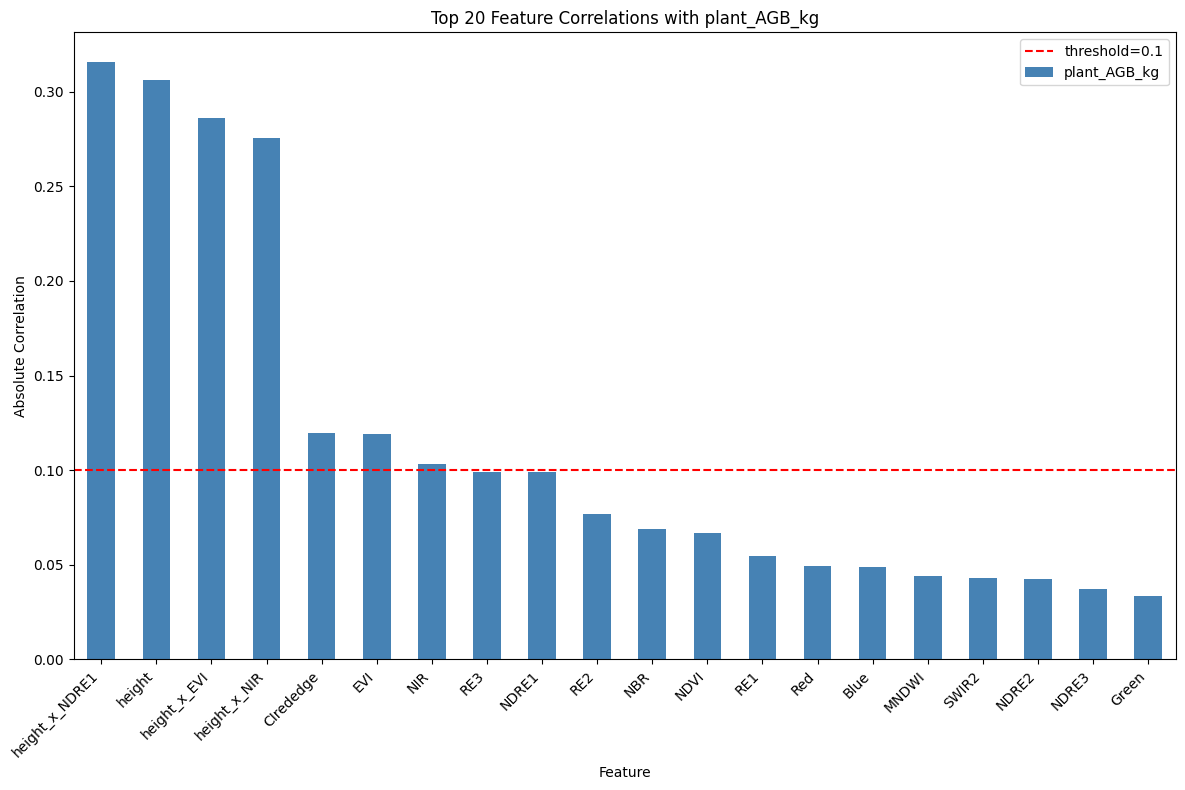

height_x_NDRE1    0.315565
height            0.305997
height_x_EVI      0.285951
height_x_NIR      0.275702
CIrededge         0.119717
EVI               0.119078
NIR               0.103383
RE3               0.099264
NDRE1             0.098902
RE2               0.076811
NBR               0.068840
NDVI              0.066806
RE1               0.054646
Red               0.049271
Blue              0.048902
MNDWI             0.044189
SWIR2             0.043206
NDRE2             0.042639
NDRE3             0.037197
Green             0.033607
Name: plant_AGB_kg, dtype: float64


In [29]:
numerical_cols = get_numerical_cols(X_belige)
target_corr = plot_correlation_matrix(X_belige[numerical_cols],
                                      y_belige,
                                      top_n=20)
print(target_corr)

## Create groups

In [30]:
n_plots = X_belige['plot_id'].nunique()
print(f"Belige : {len(X_belige)} rows, {n_plots} plots")

Belige : 3880 rows, 59 plots


In [31]:
# Retain the groups/plot_id for splitting the data based on groups.
plot_groups_belige = X_belige['plot_id'].copy()
X_belige = X_belige.drop(columns=['plot_id'])

site_groups_belige = plot_groups_belige.map(lambda x: x.rsplit('_', maxsplit=1)[0])

near_zero_sites_belige, high_agb_sites_belige,\
    near_zero_plots_belige, high_agb_plots_belige = get_low_and_high_agb_plots(y_belige,
                                                                               plot_groups_belige)

grp_belige = GROUP_INFO(near_zero_sites_belige, high_agb_sites_belige,
                        near_zero_plots_belige, high_agb_plots_belige,
                        groups=plot_groups_belige,
                        cv=test_cv)

High-AGB threshold  : 104.49 kg
Near-zero threshold : 0.004134

Near-zero variance plots:
  Big Creek_1               : log var = 0.000036
  Big Creek_4               : log var = 0.000032
  Frenchman Caye_1          : log var = 0.000753
  Frenchman Caye_2          : log var = 0.000381
  Frenchman Caye_3          : log var = 0.000693
  Frenchman Caye_4          : log var = 0.001306
  Frenchman Caye_5          : log var = 0.001283
  Frenchman Caye_6          : log var = 0.000158
  Shipstern Lagoon_1        : log var = 0.001064
  Shipstern Lagoon_3        : log var = 0.000232
  Shipstern Lagoon_4        : log var = 0.000113
  Shipstern Lagoon_5        : log var = 0.000052
  Shipstern Lagoon_6        : log var = 0.000135

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel C

### BELIGE DATA. LINEAR REGRESSION. NO GROUPS

In [39]:
%run Model_functions.ipynb
lin_belige_no_groups = {}

lin_experiment(X_belige, y_belige,
               is_groups=False, group_info=grp_belige,
               label="No groups",
               gen_features_list,
               experiments=lin_belige_no_groups,
               is_stratified=is_stratified_g)


[1/72]

 EXPERIMENT-1 No groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : 0.0131
Test RMSE   : 16.75 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0166
Train RMSE  : 16.59 kg
Num rows    : 3104
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2180
CV R² std : 0.0168
CV scores : [0.23  0.221 0.186 0.233 0.221]
 EVALUATION: EXPERIMENT-1 No groups, Model: regular, Features: ['height']

Test set:
  R²   : 0.013
  RMSE : 16.75 kg

Regular CrossValidation:
  Mean   : 0.218
  Std    : 0.017
  Scores : [0.23  0.221 0.186 0.233 0.221]

  ✅ Test R² is positive (0.013)
  ✅ CV mean is positive (0.218)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/72]

 EXPERIMENT-2 No groups, Model: ridge, Features: ['height'], ALGO: RIDGE REGRESSION: 
Test R²     : 0.0166
Test RMSE   : 16.72 kg
Train R² (log scale): 0.2200
Train R² (orig scale): 0.0181
Train RMSE  : 16.58 kg
Num rows    : 3104
Num Features: 1

 Cross-va

In [40]:
tabulate_results(lin_belige_no_groups, acceptable_only=True)

Showing 68 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,verdict
0,"EXPERIMENT-38 No groups, Model: ridge, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,0.1001,16,0.0742,16.1,0.3216,0.0379,✅ ACCEPTABLE
1,"EXPERIMENT-30 No groups, Model: ridge, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",21,0.1016,15.98,0.0755,16.09,0.3216,0.0378,✅ ACCEPTABLE
2,"EXPERIMENT-37 No groups, Model: regular, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,0.0965,16.03,0.0725,16.12,0.3214,0.0393,✅ ACCEPTABLE
3,"EXPERIMENT-29 No groups, Model: regular, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",21,0.1027,15.97,0.0771,16.08,0.3214,0.0383,✅ ACCEPTABLE
4,"EXPERIMENT-32 No groups, Model: elasticnet, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",21,0.098,16.01,0.0637,16.19,0.3177,0.0353,✅ ACCEPTABLE
5,"EXPERIMENT-40 No groups, Model: elasticnet, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,0.0987,16.01,0.0645,16.19,0.3177,0.0354,✅ ACCEPTABLE
6,"EXPERIMENT-31 No groups, Model: lasso, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",21,0.0965,16.03,0.0615,16.21,0.3163,0.0351,✅ ACCEPTABLE
7,"EXPERIMENT-39 No groups, Model: lasso, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",22,0.0964,16.03,0.0614,16.21,0.3162,0.035,✅ ACCEPTABLE
8,"EXPERIMENT-34 No groups, Model: ridge, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE']",19,0.0799,16.17,0.0533,16.28,0.3147,0.0359,✅ ACCEPTABLE
9,"EXPERIMENT-33 No groups, Model: regular, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE']",19,0.0791,16.18,0.0532,16.28,0.3145,0.0361,✅ ACCEPTABLE


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LINEAR REGRESSION

In [41]:
lin_belige_groups = {}

lin_experiment(X_belige, y_belige,
               is_groups=True, group_info=grp_belige,
               label="Plot groups",
               gen_features_list,
               experiments=lin_belige_groups,
               is_stratified=is_stratified_g)


[1/72]

 EXPERIMENT-1 Plot groups, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : 0.1515
Test RMSE   : 4.25 kg
Train R² (log scale): 0.2551
Train R² (orig scale): -0.1772
Train RMSE  : 20.15 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.1855
CV R² std : 0.2018
CV scores : [-0.029  0.568  0.095  0.134  0.16 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2296
Grouped CV R² std : 0.2175
Grouped CV scores : [-0.108  0.081  0.116 -0.026  0.407  0.535  0.582  0.187  0.21   0.313]
 EVALUATION: EXPERIMENT-1 Plot groups, Model: regular, Features: ['height']

Test set:
  R²   : 0.152
  RMSE : 4.25 kg

Regular CrossValidation:
  Mean   : 0.185
  Std    : 0.202
  Scores : [-0.029  0.568  0.095  0.134  0.16 ]

  ✅ Test R² is positive (0.152)
  ✅ CV mean is positive (0.185)

Grouped CrossValidation:
  Big Creek_5          :  -0.108  ⚠️  near-zero variance artifact
  Frenchman Caye_6     :   0.081  ✅
  Frenchman Caye_3     :   0.116 

In [42]:
tabulate_results(lin_belige_groups, acceptable_only=True)

Showing 49 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-51 Plot groups, Model: lasso, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']",8,0.2264,4.06,0.0577,18.03,0.2099,0.2179,0.2785,0.1877,0.052,none,⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-56 Plot groups, Model: elasticnet, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",11,0.2768,3.93,0.0583,18.02,0.2136,0.2164,0.2764,0.1878,0.0004,none,✅ ACCEPTABLE
2,"EXPERIMENT-72 Plot groups, Model: elasticnet, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",13,0.2768,3.93,0.0583,18.02,0.1548,0.1083,0.2741,0.1871,0.0027,none,✅ ACCEPTABLE
3,"EXPERIMENT-55 Plot groups, Model: lasso, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",11,0.2932,3.88,0.0605,18,0.2034,0.2173,0.2734,0.1899,0.0198,none,✅ ACCEPTABLE
4,"EXPERIMENT-52 Plot groups, Model: elasticnet, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1']",8,0.2284,4.05,0.0537,18.06,-0.2836,1.008,0.2729,0.1831,0.0444,none,VERDICT: ✅ ACCEPTABLE (Reg CV unstable)
5,"EXPERIMENT-68 Plot groups, Model: elasticnet, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']",10,0.211,4.1,0.0515,18.09,0.2093,0.2006,0.2701,0.1777,0.0591,none,⚠️ MARGINAL — positive metrics but concerns
6,"EXPERIMENT-71 Plot groups, Model: lasso, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",13,0.2556,3.98,0.044,18.16,0.1802,0.1747,0.2677,0.1862,0.0121,none,✅ ACCEPTABLE
7,"EXPERIMENT-67 Plot groups, Model: lasso, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2']",10,0.186,4.16,0.0477,18.12,0.1858,0.1738,0.2663,0.1814,0.0803,none,⚠️ MARGINAL — positive metrics but concerns
8,"EXPERIMENT-54 Plot groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",11,0.2863,3.9,0.0619,17.99,0.1885,0.2298,0.2659,0.1985,0.0204,1 (Big Creek_5),✅ ACCEPTABLE
9,"EXPERIMENT-70 Plot groups, Model: ridge, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1']",13,0.2877,3.9,0.0624,17.98,-1.8,4.019,0.2656,0.196,0.0221,1 (Big Creek_5),VERDICT: ✅ ACCEPTABLE (Reg CV unstable)


### BELIGE DATA. NO GROUPS. ALL ROWS. RANDOM FOREST

In [43]:
%run Model_functions.ipynb

rf_belige_no_grps = {}
rf_experiment(X_belige, y_belige,
              is_groups=False, group_info=grp_belige,
              is_grid = False,
              label="No groups",
              gen_features_list,
              experiments=rf_belige_no_grps,
              is_stratified=is_stratified_g)


[1/18]

 RANDOM FOREST: EXPERIMENT-1 No groups, Features: ['height'].
Test R²     : 0.1327
Test RMSE   : 15.70 kg
Train R² (log scale): 0.4042
Train R² (orig scale): 0.1865
Train RMSE  : 15.09 kg
Num rows    : 3104
Num Features: 1

 Cross-validation ---
CV R² mean: 0.3710
CV R² std : 0.0310
CV scores : [0.427 0.343 0.344 0.363 0.378]
 EVALUATION: EXPERIMENT-1 No groups, Features: ['height'].

Test set:
  R²   : 0.133
  RMSE : 15.70 kg

Regular CrossValidation:
  Mean   : 0.371
  Std    : 0.031
  Scores : [0.427 0.343 0.344 0.363 0.378]

  ✅ Test R² is positive (0.133)
  ✅ CV mean is positive (0.371)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/18]

 RANDOM FOREST: EXPERIMENT-2 No groups, Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].
Test R²     : 0.1327
Test RMSE   : 15.70 kg
Train R² (log scale): 0.4042
Train R² (orig scale): 0.1865
Train RMSE  : 15.09 kg
Num rows    : 3104
Num Features: 4

 Cross-validation ---
CV 

This run has a serious problem
Experiments 1 through 6 and experiment 8 all produce identical results — test R² 0.133, CV mean 0.371-0.372, CV std 0.031, train R² 0.1864-0.1865, train RMSE 15.09 kg. Eight completely different feature sets producing the exact same numbers is not a coincidence. It means the model is ignoring the spectral features entirely and predicting the same values regardless of what features it is given.
The most likely cause is that Random Forest without grouping is dominated by the target distribution — it is learning the marginal distribution of y_train_log and outputting something close to the mean for every prediction. The spectral features are contributing essentially nothing beyond what height provides in the first place.


Why this happens without grouping
Without plot-level grouping, the train/test split does not respect plot boundaries. Plants from the same plot appear in both train and test. Random Forest memorises the within-plot AGB distribution during training. When it sees test plants from the same plots, it predicts reasonably based on that memorised distribution — and that is exactly what it does regardless of which spectral features you give it, because the plot-level pattern drowns out any spectral signal.
This is a more severe form of the same leakage problem that inflated linear regression CV scores without grouping.

In [44]:
tabulate_results(rf_belige_no_grps, acceptable_only=True)

Showing 18 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,verdict
0,"EXPERIMENT-14 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.1467,15.58,0.2027,14.94,0.4085,0.0351,✅ ACCEPTABLE
1,"EXPERIMENT-13 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",8,0.1478,15.57,0.202,14.95,0.4083,0.0353,✅ ACCEPTABLE
2,"EXPERIMENT-18 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",13,0.1467,15.58,0.2023,14.95,0.4082,0.0351,✅ ACCEPTABLE
3,"EXPERIMENT-17 No groups, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",10,0.1469,15.57,0.2023,14.95,0.4079,0.0353,✅ ACCEPTABLE
4,"EXPERIMENT-16 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.1327,15.7,0.1868,15.09,0.3717,0.0307,✅ ACCEPTABLE
5,"EXPERIMENT-5 No groups, Features: ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'].",9,0.1325,15.7,0.1867,15.09,0.3717,0.0307,✅ ACCEPTABLE
6,"EXPERIMENT-6 No groups, Features: ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.1329,15.7,0.1865,15.09,0.3717,0.0307,✅ ACCEPTABLE
7,"EXPERIMENT-15 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.1328,15.7,0.1864,15.09,0.3717,0.0308,✅ ACCEPTABLE
8,"EXPERIMENT-11 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",5,0.133,15.7,0.1865,15.09,0.3716,0.0308,✅ ACCEPTABLE
9,"EXPERIMENT-12 No groups, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.1328,15.7,0.1867,15.09,0.3716,0.0307,✅ ACCEPTABLE


### BELIGE DATA. PLOT GROUPS. ALL ROWS. RANDOM FOREST (Hyper parameter tuning: NO)

In [45]:
%run Model_functions.ipynb

rf_belige_grps = {}
rf_experiment(X_belige, y_belige,
              is_groups=True, group_info=grp_belige,
              is_grid = False, label="Plot groups Grid search: No.",
              gen_features_list,
              experiments=rf_belige_grps,
              is_stratified=is_stratified_g)


[1/18]

 RANDOM FOREST: EXPERIMENT-1 Plot groups Grid search: No., Features: ['height'].
Test R²     : 0.1277
Test RMSE   : 4.31 kg
Train R² (log scale): 0.4040
Train R² (orig scale): 0.1658
Train RMSE  : 16.96 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0628
CV R² std : 0.2958
CV scores : [-0.197  0.565  0.031  0.175 -0.26 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2012
Grouped CV R² std : 0.2784
Grouped CV scores : [ 0.066 -0.36   0.251 -0.164  0.448  0.569  0.485  0.286  0.112  0.319]
 EVALUATION: EXPERIMENT-1 Plot groups Grid search: No., Features: ['height'].

Test set:
  R²   : 0.128
  RMSE : 4.31 kg

Regular CrossValidation:
  Mean   : 0.063
  Std    : 0.296
  Scores : [-0.197  0.565  0.031  0.175 -0.26 ]

  ✅ Test R² is positive (0.128)
  ✅ CV mean is positive (0.063)

Grouped CrossValidation:
  Big Creek_5          :   0.066  ✅
  Frenchman Caye_6     :  -0.360  ⚠️  near-zero variance artifact
  Frenchman Caye_3     :   0.251  ✅
  Big 

In [46]:
tabulate_results(rf_belige_grps, acceptable_only=True)

Showing 10 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-14 Plot groups Grid search: No., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.2396,4.02,0.1865,16.75,0.1022,0.2779,0.3072,0.2064,0.0676,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-18 Plot groups Grid search: No., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",13,0.2771,3.92,0.1865,16.75,0.0583,0.3049,0.3001,0.2019,0.023,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
2,"EXPERIMENT-17 Plot groups Grid search: No., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",10,0.2797,3.92,0.1866,16.75,-0.0818,0.4107,0.2775,0.2033,0.0023,1 (Big Creek_5),VERDICT: ✅ ACCEPTABLE (Reg CV unstable)
3,"EXPERIMENT-13 Plot groups Grid search: No., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",8,0.2648,3.96,0.1862,16.75,-0.0305,0.3556,0.266,0.2125,0.0012,"2 (Big Creek_5, Big Creek_3)",VERDICT: ✅ ACCEPTABLE (Reg CV unstable)
4,"EXPERIMENT-2 Plot groups Grid search: No., Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.206,4.11,0.1658,16.96,0.164,0.2314,0.2578,0.2159,0.0518,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
5,"EXPERIMENT-12 Plot groups Grid search: No., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.1853,4.17,0.1658,16.96,0.1315,0.242,0.2521,0.2039,0.0667,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
6,"EXPERIMENT-16 Plot groups Grid search: No., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.1765,4.19,0.1658,16.96,0.1232,0.247,0.2465,0.1941,0.07,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
7,"EXPERIMENT-15 Plot groups Grid search: No., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.1924,4.15,0.1658,16.96,-0.0282,0.3538,0.2029,0.2323,0.0105,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",VERDICT: ✅ ACCEPTABLE (Reg CV unstable)
8,"EXPERIMENT-1 Plot groups Grid search: No., Features: ['height'].",1,0.1277,4.31,0.1658,16.96,0.0628,0.2958,0.2012,0.2784,0.0735,"2 (Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
9,"EXPERIMENT-4 Plot groups Grid search: No., Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.246,4.01,0.1658,16.96,0.0006,0.2825,0.1946,0.2484,0.0514,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns


**"Big Creek_5          :  -0.099  ⚠️  near-zero variance artifact" - What does this mean?**  
This line is the output for one specific fold in the grouped cross-validation.  

**What is meant by fold?**  
 - In grouped cross-validation with 10 folds across 59 plots, each fold holds out a group of plots as the test set.
 - For this fold, Big Creek_5 is the primary plot that was held out — meaning the model was trained on all other plots and then asked to predict AGB for plants in Big Creek_5.

**What does -0.099 mean?**  
 - R² of -0.099 means the model performed worse than simply predicting the mean AGB for every plant in Big Creek_5.  
 - A model that just outputs the average AGB of the training set for every plant would score R² = 0.
 - Scoring -0.099 means the model's predictions were actively worse than that baseline.

**What does baseline mean?**  
 - The baseline is a dummy model that ignores all features entirely and simply predicts the mean AGB of the training set for every single plant.
 - Say the mean AGB of all training plants is 8 kg. The baseline model would predict 8 kg for every plant in Big Creek_5, regardless of its height, spectral values, or species. No learning, no features — just the same number repeated for every plant.

R² = 0 means your model performs exactly as well as this dummy baseline.  
R² > 0 means your model beats the dummy.  
R² < 0 means your model is worse than the dummy — it would have been better to just predict the mean for everyone.  


**Why this happens — the near-zero variance problem?**  
 - Big Creek_5 is one of the near-zero variance plots. 
 - Its plants all weigh almost nothing — the AGB values are clustered extremely tightly around a very small number like 0.003 kg.  

R² is computed as:  
R² = 1 - (sum of squared residuals / variance of test set)  

When the test set has near-zero variance — meaning all true values are almost identical — the denominator approaches zero. Even a very small prediction error in the numerator produces a catastrophically bad R² score.  
So -0.128 does not mean the model made large errors. It means the denominator was so small that even tiny errors look catastrophic mathematically.


**Why it is labelled ⚠️ and not ❌?**  
 - The ⚠️ near-zero variance artifact label means the evaluation function identified this as a mathematical breakdown of the R² metric rather than a genuine model failure.
 - The model is not failing to predict AGB for Big Creek_5 plants — it simply cannot be evaluated with R² on a holdout set where all true values are essentially the same number.
 -  This is why these folds are excluded from the high-AGB failure check and from the unexplained negatives check. They are not counted against the model.

**Why this happens for Big Creek_5?**  
 - Big Creek_5 plants all weigh around 0.003 kg.
 - The training set mean is much higher — say 8 kg.
 - So the dummy baseline predicts 8 kg for every Big Creek_5 plant, which is already a terrible prediction.
 - Your model predicts something different — perhaps 2 kg or 5 kg based on the spectral features — which is also wrong, but the R² formula punishes it even more harshly than the dummy because the variance of the test set is essentially zero.
 - So the -0.128 is not saying the model predicted worse than 8 kg for every plant. It is saying the R² formula, given near-zero variance in the test set, makes the model look worse than the dummy even when both are making similarly bad predictions. This is the mathematical artifact we have been labelling as ⚠️.

### BELIGE DATA. PLOT GROUPS. ALL ROWS. RANDOM FOREST (Hyper parameter tuning: Yes)

In [47]:
%run Model_functions.ipynb

rf_belige_no_grid_grps = {}
rf_experiment(X_belige, y_belige,
              is_groups=True, group_info=grp_belige,
              is_grid = True,
              label="Plot groups. Grid search: Yes.",
              gen_features_list,
              experiments=rf_belige_no_grid_grps,
              is_stratified=is_stratified_g)


[1/18]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 100, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 0.5, 'max_depth': 5}

 RANDOM FOREST: EXPERIMENT-1 Plot groups. Grid search: Yes., Features: ['height'].
Test R²     : 0.1378
Test RMSE   : 4.29 kg
Train R² (log scale): 0.3906
Train R² (orig scale): 0.1398
Train RMSE  : 17.22 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.1506
CV R² std : 0.2367
CV scores : [-0.184  0.537  0.168  0.207  0.026]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2464
Grouped CV R² std : 0.2156
Grouped CV scores : [ 0.072 -0.018  0.237 -0.162  0.427  0.555  0.491  0.265  0.25   0.346]
 EVALUATION: EXPERIMENT-1 Plot groups. Grid search: Yes., Features: ['height'].

Test set:
  R²   : 0.138
  RMSE : 4.29 kg

Regular CrossValidation:
  Mean   : 0.151
  Std    : 0.237
  Scores : [-0.184  0.537  0.168  0.207  0.026]

  ✅ Test R² is positive (0.138)
  ✅ CV mean is positi

In [48]:
tabulate_results(rf_belige_no_grid_grps, acceptable_only=True)

Showing 14 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-14 Plot groups. Grid search: Yes., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.2252,4.06,0.1594,17.03,0.2001,0.2096,0.3019,0.2025,0.0766,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-18 Plot groups. Grid search: Yes., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",13,0.2271,4.06,0.1699,16.92,0.1739,0.2411,0.2937,0.1991,0.0665,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
2,"EXPERIMENT-13 Plot groups. Grid search: Yes., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",8,0.2375,4.03,0.144,17.18,0.1064,0.2709,0.2709,0.2026,0.0334,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
3,"EXPERIMENT-17 Plot groups. Grid search: Yes., Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",10,0.2161,4.09,0.1628,16.99,0.0675,0.3067,0.2669,0.1953,0.0508,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
4,"EXPERIMENT-2 Plot groups. Grid search: Yes., Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.2064,4.11,0.1547,17.07,0.231,0.2173,0.2625,0.2096,0.0561,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
5,"EXPERIMENT-12 Plot groups. Grid search: Yes., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.1913,4.15,0.1574,17.05,0.2,0.2186,0.2559,0.2045,0.0646,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
6,"EXPERIMENT-4 Plot groups. Grid search: Yes., Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.2433,4.01,0.1596,17.02,0.0771,0.1962,0.2526,0.205,0.0093,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
7,"EXPERIMENT-16 Plot groups. Grid search: Yes., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.0873,4.41,0.1598,17.02,0.179,0.2407,0.249,0.1845,0.1618,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
8,"EXPERIMENT-1 Plot groups. Grid search: Yes., Features: ['height'].",1,0.1378,4.29,0.1398,17.22,0.1506,0.2367,0.2464,0.2156,0.1086,"2 (Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
9,"EXPERIMENT-11 Plot groups. Grid search: Yes., Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",5,0.0876,4.41,0.1247,17.37,0.1039,0.278,0.2283,0.2035,0.1407,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. XGBOOST (Hyper parameter tuning: No)

In [49]:
%run Model_functions.ipynb

xg_belige_no_grid_grps = {}
xgboost_experiment(X_belige, y_belige,
                   is_groups=True, group_info=grp_belige,
                   is_grid=False,
                   label="Plot groups. Grid search: No",
                   gen_features_list,
                   experiments=xg_belige_no_grid_grps,
                   is_stratified=is_stratified_g)


[1/18]

 XGBOOST: EXPERIMENT-1 Plot groups. Grid search: No, Features: ['height'].
Test R²     : 0.1187
Test RMSE   : 4.33 kg
Train R² (log scale): 0.2290
Train R² (orig scale): -0.0122
Train RMSE  : 18.68 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.1260
CV R² std : 0.1651
CV scores : [0.    0.446 0.031 0.122 0.03 ]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2468
Grouped CV R² std : 0.1956
Grouped CV scores : [ 0.073  0.065  0.239 -0.092  0.457  0.505  0.512  0.282  0.114  0.314]
 EVALUATION: EXPERIMENT-1 Plot groups. Grid search: No, Features: ['height'].

Test set:
  R²   : 0.119
  RMSE : 4.33 kg

Regular CrossValidation:
  Mean   : 0.126
  Std    : 0.165
  Scores : [0.    0.446 0.031 0.122 0.03 ]

  ✅ Test R² is positive (0.119)
  ✅ CV mean is positive (0.126)

Grouped CrossValidation:
  Big Creek_5          :   0.073  ✅
  Frenchman Caye_6     :   0.065  ✅
  Frenchman Caye_3     :   0.239  ✅
  Big Creek_3          :  -0.092  ⚠️  near-zero var

In [50]:
tabulate_results(xg_belige_no_grid_grps, acceptable_only=True)

Showing 11 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-2 Plot groups. Grid search: No, Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.1298,4.31,-0.0097,18.66,0.1438,0.1642,0.2543,0.2041,0.1245,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-14 Plot groups. Grid search: No, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.0883,4.41,-0.0056,18.62,0.0123,0.1807,0.2485,0.165,0.1602,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
2,"EXPERIMENT-1 Plot groups. Grid search: No, Features: ['height'].",1,0.1187,4.33,-0.0122,18.68,0.126,0.1651,0.2468,0.1956,0.1281,1 (Big Creek_3),⚠️ MARGINAL — positive metrics but concerns
3,"EXPERIMENT-4 Plot groups. Grid search: No, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.2117,4.1,0.017,18.41,0.0877,0.2025,0.2269,0.2111,0.0152,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
4,"EXPERIMENT-12 Plot groups. Grid search: No, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.0415,4.52,-0.0232,18.78,0.1394,0.2166,0.2119,0.1886,0.1704,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
5,"EXPERIMENT-11 Plot groups. Grid search: No, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",5,0.0833,4.42,-0.0108,18.67,0.0761,0.2579,0.2096,0.2042,0.1263,"2 (Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
6,"EXPERIMENT-16 Plot groups. Grid search: No, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.0965,4.39,-0.0109,18.67,0.1125,0.2025,0.1971,0.1975,0.1006,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
7,"EXPERIMENT-10 Plot groups. Grid search: No, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",22,0.106,4.36,-0.0103,18.66,0.0319,0.246,0.1869,0.2441,0.0809,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
8,"EXPERIMENT-9 Plot groups. Grid search: No, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'].",19,0.0996,4.38,-0.0101,18.66,0.0337,0.2677,0.1789,0.2791,0.0794,"2 (Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
9,"EXPERIMENT-15 Plot groups. Grid search: No, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.0483,4.5,-0.023,18.78,0.0334,0.2353,0.1571,0.3004,0.1088,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. XGBOOST (Hyper parameter tuning: Yes)

In [51]:
%run Model_functions.ipynb

xg_belige_grid_grps = {}
xgboost_experiment(X_belige, y_belige,
                   is_groups=True, group_info=grp_belige,
                   is_grid = True,
                   label="Plot groups. Grid search: Yes",
                   gen_features_list,
                   experiments=xg_belige_grid_grps,
                   is_stratified=is_stratified_g)


[1/18]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

 XGBOOST: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].
Test R²     : 0.1217
Test RMSE   : 4.33 kg
Train R² (log scale): 0.3939
Train R² (orig scale): 0.1213
Train RMSE  : 17.41 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.1910
CV R² std : 0.1397
CV scores : [0.004 0.439 0.162 0.171 0.179]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2669
Grouped CV R² std : 0.1799
Grouped CV scores : [ 0.08   0.127  0.246 -0.058  0.42   0.54   0.504  0.277  0.202  0.331]
 EVALUATION: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].

Test set:
  R²   : 0.122
  RMSE : 4.33 kg

Regular CrossValidation:
  Mean   : 0.191
  Std    : 0.140
  Scores : [0.004 0.439 0.162 0.171 0.179]

  ✅ Test R²

In [52]:
tabulate_results(xg_belige_grid_grps, acceptable_only=True)

Showing 11 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].",1,0.1217,4.33,0.1213,17.41,0.191,0.1397,0.2669,0.1799,0.1452,1 (Big Creek_3),⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-18 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",13,0.1318,4.3,0.1851,16.76,0.1199,0.2307,0.2646,0.1673,0.1327,1 (Big Creek_3),⚠️ MARGINAL — positive metrics but concerns
2,"EXPERIMENT-14 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.1871,4.16,0.0899,17.71,0.1205,0.1606,0.2603,0.1627,0.0732,1 (Big Creek_5),⚠️ MARGINAL — positive metrics but concerns
3,"EXPERIMENT-2 Plot groups. Grid search: Yes, Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.2186,4.08,0.1225,17.4,0.1925,0.153,0.2588,0.1969,0.0403,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
4,"EXPERIMENT-13 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",8,0.0933,4.39,0.0743,17.87,0.0906,0.2431,0.2554,0.1883,0.1621,none,⚠️ MARGINAL — positive metrics but concerns
5,"EXPERIMENT-17 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",10,0.1583,4.23,0.075,17.86,0.0545,0.2402,0.2378,0.211,0.0795,1 (Frenchman Caye_6),⚠️ MARGINAL — positive metrics but concerns
6,"EXPERIMENT-12 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.1283,4.31,0.0895,17.72,0.1846,0.1738,0.226,0.1853,0.0977,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
7,"EXPERIMENT-16 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",10,0.1558,4.24,0.0872,17.74,0.1511,0.1643,0.1899,0.2233,0.0341,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",✅ ACCEPTABLE
8,"EXPERIMENT-6 Plot groups. Grid search: Yes, Features: ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.1855,4.17,0.0132,18.45,0.0996,0.2275,0.139,0.2212,0.0465,"3 (Big Creek_5, Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
9,"EXPERIMENT-4 Plot groups. Grid search: Yes, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.1645,4.22,0.1695,16.92,0.14,0.2118,0.0817,0.4235,0.0828,"4 (Big Creek_5, Frenchman Caye_6, Big Creek_3, Big Creek_2)",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LGBM (Hyper parameter tuning: No)

In [53]:
%run Model_functions.ipynb

lgbm_belige_no_grid_grps = {}
lgbm_experiment(X_belige, y_belige,
                is_groups=True, group_info=grp_belige,
                is_grid = False,
                label="Plot groups. Grid search: Yes",
                gen_features_list,
                experiments=lgbm_belige_no_grid_grps,
                is_stratified=is_stratified_g)


[1/18]

 LIGHTGBM: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].
Test R²     : 0.1322
Test RMSE   : 4.30 kg
Train R² (log scale): 0.4003
Train R² (orig scale): 0.1462
Train RMSE  : 17.16 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0796
CV R² std : 0.2890
CV scores : [-0.196  0.567  0.08   0.176 -0.229]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2093
Grouped CV R² std : 0.2722
Grouped CV scores : [ 0.106 -0.363  0.25  -0.129  0.451  0.563  0.486  0.286  0.123  0.32 ]
 EVALUATION: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].

Test set:
  R²   : 0.132
  RMSE : 4.30 kg

Regular CrossValidation:
  Mean   : 0.080
  Std    : 0.289
  Scores : [-0.196  0.567  0.08   0.176 -0.229]

  ✅ Test R² is positive (0.132)
  ✅ CV mean is positive (0.080)

Grouped CrossValidation:
  Big Creek_5          :   0.106  ✅
  Frenchman Caye_6     :  -0.363  ⚠️  near-zero variance artifact
  Frenchman Caye_3     :   0.250  ✅
  Big Cre

In [54]:
tabulate_results(lgbm_belige_no_grid_grps, acceptable_only=True)

Showing 4 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-2 Plot groups. Grid search: Yes, Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.1671,4.21,0.1494,17.13,0.1646,0.2192,0.2619,0.2058,0.0948,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].",1,0.1322,4.3,0.1462,17.16,0.0796,0.289,0.2093,0.2722,0.0771,"2 (Frenchman Caye_6, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
2,"EXPERIMENT-4 Plot groups. Grid search: Yes, Features: ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",12,0.0655,4.46,0.1659,16.96,0.0355,0.1487,0.1977,0.2183,0.1321,"2 (Big Creek_5, Big Creek_3)",⚠️ MARGINAL — positive metrics but concerns
3,"EXPERIMENT-12 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.0282,4.55,0.166,16.96,0.0248,0.3791,0.1838,0.2171,0.1556,"3 (Big Creek_5, Big Creek_3, Big Creek_2)",⚠️ MARGINAL — positive metrics but concerns


### BELIGE DATA. PLOT GROUPS. ALL ROWS. LGBM (Hyper parameter tuning: Yes)

In [55]:
%run Model_functions.ipynb

lgbm_belige_grid_grps = {}
lgbm_experiment(X_belige, y_belige,
                is_groups=True, group_info=grp_belige,
                is_grid = True,
                label="Plot groups. Grid search: Yes",
                gen_features_list,
                experiments=lgbm_belige_grid_grps,
                is_stratified=is_stratified_g)


[1/18]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'subsample': 1.0, 'reg_lambda': 10, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

 LIGHTGBM: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].
Test R²     : 0.2145
Test RMSE   : 4.09 kg
Train R² (log scale): 0.3405
Train R² (orig scale): 0.0386
Train RMSE  : 18.21 kg
Num rows    : 3100
Num Features: 1

 Cross-validation ---
CV R² mean: 0.2050
CV R² std : 0.1963
CV scores : [-0.111  0.491  0.157  0.192  0.296]

Grouped Cross-validation ---
Grouped CV R² mean: 0.2831
Grouped CV R² std : 0.1899
Grouped CV scores : [ 0.072  0.224  0.229 -0.068  0.394  0.565  0.581  0.251  0.244  0.337]
 EVALUATION: EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].

Test set:
  R²   : 0.214
  RMSE : 4.09 kg

Regular CrossValidation:
  Mean   : 0.205
  Std    : 0.196
  Scores : [-0.111  0.491  0

In [56]:
tabulate_results(lgbm_belige_grid_grps, acceptable_only=True)

Showing 16 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,Group CV R² Mean,Group CV R² Std,CV-Test Gap,-ve Folds,verdict
0,"EXPERIMENT-1 Plot groups. Grid search: Yes, Features: ['height'].",1,0.2145,4.09,0.0386,18.21,0.205,0.1963,0.2831,0.1899,0.0686,1 (Big Creek_3),⚠️ MARGINAL — positive metrics but concerns
1,"EXPERIMENT-11 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",5,0.2376,4.03,0.0485,18.11,0.1446,0.2246,0.2805,0.1811,0.0429,1 (Big Creek_3),✅ ACCEPTABLE
2,"EXPERIMENT-2 Plot groups. Grid search: Yes, Features: ['height', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",4,0.2468,4.01,0.0505,18.09,0.2355,0.2177,0.2755,0.2024,0.0287,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
3,"EXPERIMENT-13 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1'].",8,0.2093,4.1,0.0139,18.44,0.1189,0.2232,0.267,0.1787,0.0576,1 (Big Creek_3),⚠️ MARGINAL — positive metrics but concerns
4,"EXPERIMENT-9 Plot groups. Grid search: Yes, Features: ['height', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE'].",19,0.2124,4.1,0.046,18.14,0.1198,0.2111,0.2606,0.1761,0.0482,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
5,"EXPERIMENT-15 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",7,0.2275,4.06,0.0482,18.12,0.1486,0.2263,0.2575,0.1628,0.03,1 (Big Creek_3),✅ ACCEPTABLE
6,"EXPERIMENT-14 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",11,0.2085,4.11,0.0069,18.51,0.1488,0.2299,0.253,0.1888,0.0445,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
7,"EXPERIMENT-18 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",13,0.2067,4.11,0.007,18.5,0.148,0.2279,0.2466,0.178,0.0399,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE
8,"EXPERIMENT-17 Plot groups. Grid search: Yes, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2'].",10,0.2178,4.08,0.0058,18.52,0.1114,0.2227,0.2409,0.1562,0.0231,none,✅ ACCEPTABLE
9,"EXPERIMENT-12 Plot groups. Grid search: Yes, Features: ['height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].",8,0.2071,4.11,0.0062,18.51,0.1677,0.2291,0.2402,0.1971,0.0331,"2 (Big Creek_5, Big Creek_3)",✅ ACCEPTABLE


**COMMENTS:**  
Many of the gradient boosting variants — XGBoost no grid, XGBoost with grid, LGBM no grid, with and without interaction terms produced zero acceptable results.

Tuned LGBM finally worked but remains consistently weaker than RF across all metrics.  
Grouped CV is ~0.02–0.04 lower, test R² is ~0.04–0.05 lower across matched experiments.

Gradient boosting can work on this dataset with extreme regularisation, but it requires tuning that essentially limits it to shallow trees and very slow learning — at which point it is doing less than what RF does naturally via bagging. 

The conclusion is definitve that the Gradient boosting methods are categorically not suited to this dataset structure.  
With only 59 plots and high within-plot variance, bagging (RF) will always outperform boosting.

### BELIGE DATA. PLOT GROUPS. ALL ROWS. MERF (Hyper parameter tuning: NO)

In [ ]:
%run Model_functions.ipynb

merf_belige_no_grid_grps = {}
merf_experiment(X_belige, y_belige,
                is_groups=True, group_info=grp_belige,
                is_grid = False,
                label="Plot groups. Grid search: NO",
                features_list=gen_features_list,
                experiments=merf_belige_no_grid_grps,
                is_stratified=is_stratified_g)


[1/18]
MERF model fitting starts


### BELIGE DATA. PLOT GROUPS. ALL ROWS. MERF (Hyper parameter tuning: Yes)

In [ ]:
%run Model_functions.ipynb

merf_belige_no_grid_grps = {}
merf_experiment(X_belige, y_belige,
                is_groups=True, group_info=grp_belige,
                is_grid = True,
                label="Plot groups. Grid search: Yes",
                features_list=gen_features_list,
                experiments=merf_belige_no_grid_grps,
                is_stratified=is_stratified_g)

# BELIGE DATA. PLOT-AVERAGE

In [220]:
belige_plot_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()

# Select TANDEMX
belige_plot_df_avg = belige_plot_df.drop(columns=['height'])
belige_plot_df_avg = belige_plot_df_avg.rename({'tandemx_height_m': 'height'}, axis=1)
belige_plot_df_avg = belige_plot_df_avg.drop(columns=['simard_height_m'])
belige_plot_df_avg.columns

Index(['dataset', 'plot_id', 'start_date', 'end_date', 'latitude', 'longitude',
       'diameter', 'species', 'plant_AGB_kg', 'capture_start', 'capture_end',
       'sentinel_time', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR',
       'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2',
       'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'cloud_threshold_used',
       'height'],
      dtype='object')

In [221]:
PLOT_AREA_HA = 0.0154  # Kauffman and Donato 2012

# Sentinel-2 band and index columns
s2_band_cols  = ['Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3', 'NIR', 'SWIR1', 'SWIR2']
s2_index_cols = ['NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1', 'NDRE2', 'NDRE3', 
                 'CIrededge', 'CLOUD_COVERAGE']
coord_cols    = ['latitude', 'longitude']
height_cols   = ['height']   # already renamed from tandemx_height_m

eo_cols       = s2_band_cols + s2_index_cols + height_cols + coord_cols

agg_dict = {}
agg_dict['plant_AGB_kg'] = ['sum', 'count']
agg_dict['diameter']     = 'mean'
for col in eo_cols:
    if col in belige_plot_df_avg.columns:
        agg_dict[col] = 'mean'

plot_df = belige_plot_df_avg.groupby('plot_id').agg(agg_dict).reset_index()

# Flatten multi-level columns
plot_df.columns = ['plot_id'] + [
    f"{col}_{agg}" if isinstance(agg, str) and agg in ['sum', 'count', 'mean']
    else col
    for col, agg in plot_df.columns[1:]
]

# Compute AGB in Mg/ha
plot_df['AGB_Mg_ha'] = (plot_df['plant_AGB_kg_sum'] / 1000) / PLOT_AREA_HA

print(f"Plot-level rows  : {len(plot_df)}")
print(f"\nAGB_Mg_ha range  : {plot_df['AGB_Mg_ha'].min():.2f} to {plot_df['AGB_Mg_ha'].max():.2f}")
print(f"AGB_Mg_ha mean   : {plot_df['AGB_Mg_ha'].mean():.2f}")

plot_df.columns

Plot-level rows  : 59

AGB_Mg_ha range  : 0.01 to 98.26
AGB_Mg_ha mean   : 17.98


Index(['plot_id', 'plant_AGB_kg_sum', 'plant_AGB_kg_count', 'diameter_mean',
       'Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean',
       'RE3_mean', 'NIR_mean', 'SWIR1_mean', 'SWIR2_mean', 'NDVI_mean',
       'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean',
       'NDRE3_mean', 'CIrededge_mean', 'CLOUD_COVERAGE_mean', 'height_mean',
       'latitude_mean', 'longitude_mean', 'AGB_Mg_ha'],
      dtype='object')

In [222]:
non_feature_cols = [
    'total_AGB_kg',
    'AGB_Mg_ha',
    'latitude',
    'longitude',
    'diameter_mean',
    'latitude_mean',
    'longitude_mean'
]

targets = ['AGB_Mg_ha', 'plant_AGB_kg_sum']
target  = 'AGB_Mg_ha'

sentinel_cols  = ['Blue_mean', 'Green_mean', 'Red_mean',
                  'RE1_mean', 'RE2_mean', 'RE3_mean',
                  'NIR_mean', 'SWIR1_mean', 'SWIR2_mean',
                  'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean',
                  'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean',
                  'CIrededge_mean', 'CLOUD_COVERAGE_mean']

feature_cols_avg = [c for c in plot_df.columns if c not in targets and c not in non_feature_cols]

X_plot = plot_df[feature_cols_avg]
y_plot = plot_df[target]

In [223]:
X_plot.columns

Index(['plot_id', 'plant_AGB_kg_count', 'Blue_mean', 'Green_mean', 'Red_mean',
       'RE1_mean', 'RE2_mean', 'RE3_mean', 'NIR_mean', 'SWIR1_mean',
       'SWIR2_mean', 'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean',
       'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean',
       'CLOUD_COVERAGE_mean', 'height_mean'],
      dtype='object')

In [224]:
print(f"Non-Sentinel Features : {set(feature_cols_avg) - set(sentinel_cols)}")

Non-Sentinel Features : {'plot_id', 'height_mean', 'plant_AGB_kg_count'}


In [225]:
print(f"Sentinel Features : {set(feature_cols_avg) - set(non_feature_cols) - set(['plot_id'])}")

Sentinel Features : {'NBR_mean', 'CLOUD_COVERAGE_mean', 'NDRE1_mean', 'MNDWI_mean', 'RE3_mean', 'RE2_mean', 'EVI_mean', 'Green_mean', 'NIR_mean', 'plant_AGB_kg_count', 'NDRE3_mean', 'Red_mean', 'Blue_mean', 'SWIR2_mean', 'NDRE2_mean', 'SWIR1_mean', 'CIrededge_mean', 'height_mean', 'RE1_mean', 'NDVI_mean'}


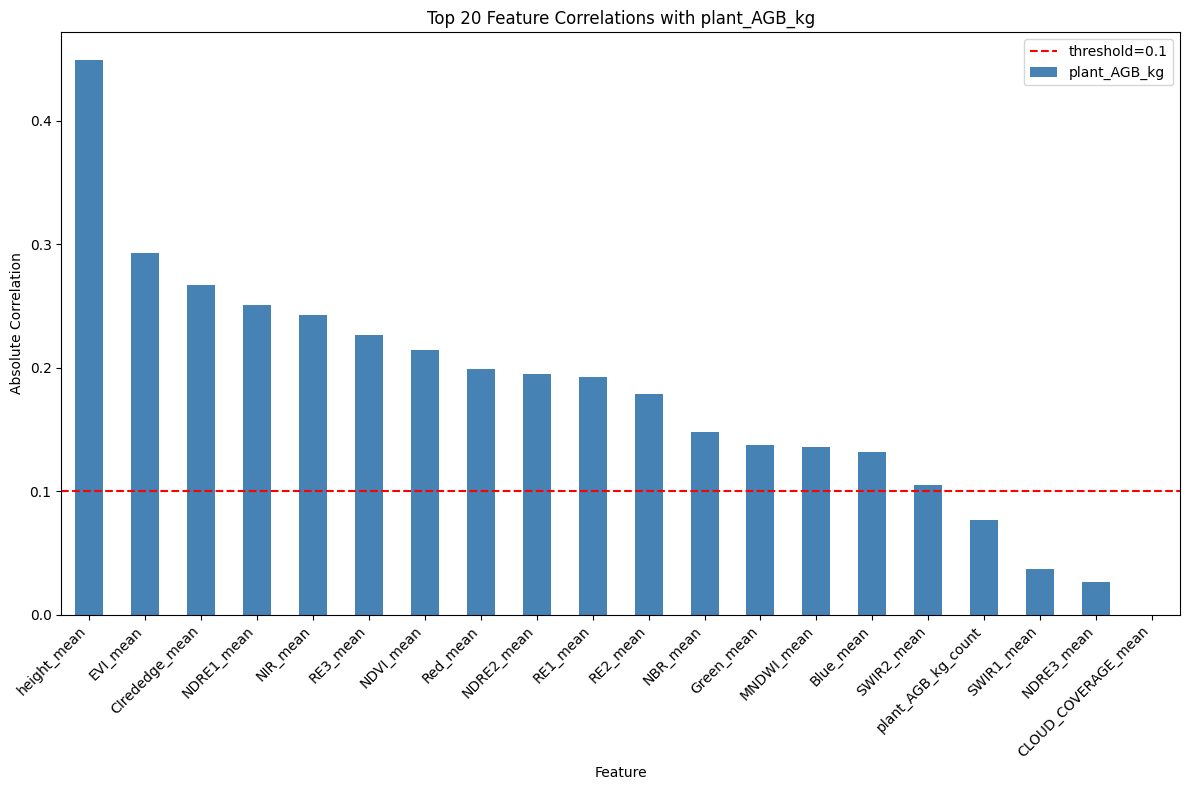

height_mean            0.449033
EVI_mean               0.293036
CIrededge_mean         0.267157
NDRE1_mean             0.250277
NIR_mean               0.242700
RE3_mean               0.225970
NDVI_mean              0.214131
Red_mean               0.199162
NDRE2_mean             0.194402
RE1_mean               0.192343
RE2_mean               0.178787
NBR_mean               0.147452
Green_mean             0.136956
MNDWI_mean             0.135677
Blue_mean              0.131772
SWIR2_mean             0.105008
plant_AGB_kg_count     0.076747
SWIR1_mean             0.037037
NDRE3_mean             0.026120
CLOUD_COVERAGE_mean         NaN
Name: plant_AGB_kg, dtype: float64


In [226]:
numerical_cols = get_numerical_cols(X_plot)
target_corr = plot_correlation_matrix(X_plot[numerical_cols],
                                      y_plot,
                                      top_n=20)
print(target_corr)

In [227]:
X_plot = X_plot.drop(columns=['CLOUD_COVERAGE_mean'])

In [228]:
features_list_avg = [
    ['height_mean'],
    ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean'],
    ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean'],
    ['Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 
     'NIR_mean', 'SWIR1_mean', 'SWIR2_mean'],
    ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 
     'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'],
    ['height_mean', 'Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean',
     'NIR_mean', 'SWIR1_mean', 'SWIR2_mean', 'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean',
     'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'],
]

In [233]:
test_cv = 5

if 'plot_id' in X_plot.columns:
    X_plot = X_plot.drop(columns=['plot_id'])

# Near-zero and high AGB for evaluation — based directly on y values
low_threshold  = y_plot.quantile(0.25)
high_threshold = y_plot.quantile(0.75)

near_zero_plots_avg = y_plot[y_plot <= low_threshold].index.tolist()
high_agb_plots_avg  = y_plot[y_plot >= high_threshold].index.tolist()

print(f"Near-zero plots : {len(near_zero_plots_avg)}")
print(f"High-AGB plots  : {len(high_agb_plots_avg)}")

grp_belige_avg = GROUP_INFO(None, None,
                            near_zero_plots_avg, high_agb_plots_avg,
                            groups=None,
                            cv=test_cv)

Near-zero plots : 15
High-AGB plots  : 15


### BELIGE. PLOT-AVEAGE. LINEAR REGRESSION

In [235]:
%run Model_functions.ipynb
lin_belige_plot_avg = {}

lin_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               label="Plot average,",
               features_list=features_list_avg,
               lin_experiments=lin_belige_plot_avg,
               is_stratified=is_stratified_g)


[1/24]

 EXPERIMENT-1 Plot average,, Model: regular, Features: ['height_mean'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0397
Test RMSE   : 17.19 kg
Train R² (log scale): 0.2404
Train R² (orig scale): -0.8533
Train RMSE  : 33.63 kg
Num rows    : 47
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0503
CV R² std : 0.2225
CV scores : [ 0.048  0.158 -0.378  0.195  0.228]
 EVALUATION: EXPERIMENT-1 Plot average,, Model: regular, Features: ['height_mean']

Test set:
  R²   : -0.040
  RMSE : 17.19 kg

Regular CrossValidation:
  Mean   : 0.050
  Std    : 0.223
  Scores : [ 0.048  0.158 -0.378  0.195  0.228]

  ❌ Test R² is negative (-0.040)
  ✅ CV mean is positive (0.050)

────────────────────────────────────────────────────────────
VERDICT: ❌ REJECTED

[2/24]

 EXPERIMENT-2 Plot average,, Model: ridge, Features: ['height_mean'], ALGO: RIDGE REGRESSION: 
Test R²     : -0.0938
Test RMSE   : 17.63 kg
Train R² (log scale): 0.2330
Train R² (orig scale): -0.1969
Train RMSE  : 27.03 kg
Num ro

Key findings

Exp 23 (Lasso, all features) — Test R² 0.832 is suspicious. CV mean is −0.024 with a fold score of −1.09. This is a classic sign of lucky test split, not genuine generalisation. The model fits 18 features on 47 rows — severely underdetermined. Lasso is shrinking aggressively but the test set happened to align well. Discard.

Exp 24 (ElasticNet, all features) — Test R² 0.801, CV mean 0.066. Same problem — CV is near zero while test is 0.80. The gap is too large to trust.

Exp 21 (OLS, all features) — Test R² −1,888,670. Perfect illustration of what happens when you fit 18 features on 47 rows with no regularisation. Complete numerical collapse.

The genuinely trustworthy results are Exp 5–12 — height + spectral subsets with moderate feature counts. 
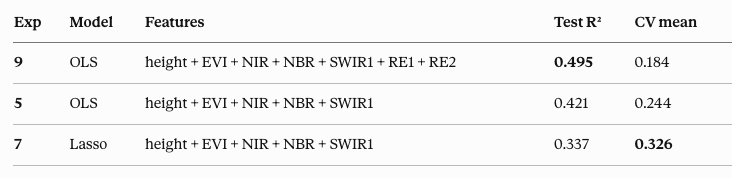

Exp 9 has the best test R² among honest models. Exp 7 has the best CV mean with tight std. The plot-level signal is real and stronger than the tree-level results (0.49 vs 0.28), which makes sense — plot averaging suppresses within-plot noise.

The consistent message: height_mean combined with a handful of spectral features is the right feature set. All-feature models are too many parameters for 59 plots.

In [236]:
%run Model_functions.ipynb
tabulate_results(lin_belige_plot_avg, acceptable_only=True)

Showing 16 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,verdict
0,"EXPERIMENT-7 Plot average,, Model: lasso, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean']",5,0.3373,13.72,-0.0253,25.02,0.3263,0.218,✅ ACCEPTABLE
1,"EXPERIMENT-8 Plot average,, Model: elasticnet, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean']",5,0.3443,13.65,-0.0272,25.04,0.3222,0.2128,✅ ACCEPTABLE
2,"EXPERIMENT-11 Plot average,, Model: lasso, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean']",7,0.3373,13.72,-0.0253,25.02,0.3219,0.2233,✅ ACCEPTABLE
3,"EXPERIMENT-6 Plot average,, Model: ridge, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean']",5,0.3564,13.52,-0.0296,25.07,0.3194,0.2546,✅ ACCEPTABLE
4,"EXPERIMENT-12 Plot average,, Model: elasticnet, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean']",7,0.3443,13.65,-0.0272,25.04,0.3168,0.2193,✅ ACCEPTABLE
5,"EXPERIMENT-10 Plot average,, Model: ridge, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean']",7,0.353,13.56,-0.0287,25.06,0.2592,0.2683,✅ ACCEPTABLE
6,"EXPERIMENT-5 Plot average,, Model: regular, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean']",5,0.4207,12.83,-0.0446,25.25,0.2439,0.1503,✅ ACCEPTABLE
7,"EXPERIMENT-19 Plot average,, Model: lasso, Features: ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean']",8,0.3049,14.05,-0.0789,25.66,0.2334,0.1961,✅ ACCEPTABLE
8,"EXPERIMENT-20 Plot average,, Model: elasticnet, Features: ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean']",8,0.2986,14.12,-0.0735,25.6,0.1987,0.1705,✅ ACCEPTABLE
9,"EXPERIMENT-9 Plot average,, Model: regular, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean']",7,0.4949,11.98,0.0247,24.4,0.1837,0.1342,✅ ACCEPTABLE


In [ ]:
### BELIGE. PLOT-AVEAGE. LINEAR REGRESSION {Hyperparameter tuning: NO}

In [238]:
%run Model_functions.ipynb

rf_belige_avg_no_grid = {}
rf_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               is_grid=False,
               label="Plot average,",
               features_list=features_list_avg,
               rf_experiments=rf_belige_avg_no_grid,
               is_stratified=is_stratified_g)


[1/6]

 RANDOM FOREST: EXPERIMENT-1 Plot average,, Features: ['height_mean'].
Test R²     : 0.5793
Test RMSE   : 10.93 kg
Train R² (log scale): 0.7536
Train R² (orig scale): 0.4702
Train RMSE  : 17.98 kg
Num rows    : 47
Num Features: 1

 Cross-validation ---
CV R² mean: 0.3062
CV R² std : 0.1270
CV scores : [0.32  0.132 0.207 0.377 0.494]
 EVALUATION: EXPERIMENT-1 Plot average,, Features: ['height_mean'].

Test set:
  R²   : 0.579
  RMSE : 10.93 kg

Regular CrossValidation:
  Mean   : 0.306
  Std    : 0.127
  Scores : [0.32  0.132 0.207 0.377 0.494]

  ✅ Test R² is positive (0.579)
  ✅ CV mean is positive (0.306)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/6]

 RANDOM FOREST: EXPERIMENT-2 Plot average,, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean'].
Test R²     : 0.5447
Test RMSE   : 11.37 kg
Train R² (log scale): 0.8549
Train R² (orig scale): 0.5647
Train RMSE  : 16.30 kg
Num rows    : 47
Num Features: 5

 Cro

In [239]:
%run Model_functions.ipynb
tabulate_results(rf_belige_avg_no_grid, acceptable_only=True)

Showing 6 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,verdict
0,"EXPERIMENT-6 Plot average,, Features: ['height_mean', 'Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 'NIR_mean', 'SWIR1_mean', 'SWIR2_mean', 'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'].",18,0.7101,9.07,0.6076,15.48,0.6411,0.2301,✅ ACCEPTABLE
1,"EXPERIMENT-5 Plot average,, Features: ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'].",8,0.5682,11.08,0.554,16.5,0.5826,0.2383,✅ ACCEPTABLE
2,"EXPERIMENT-3 Plot average,, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean'].",7,0.5766,10.97,0.5583,16.42,0.582,0.2486,✅ ACCEPTABLE
3,"EXPERIMENT-2 Plot average,, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean'].",5,0.5447,11.37,0.5647,16.3,0.5603,0.2424,✅ ACCEPTABLE
4,"EXPERIMENT-4 Plot average,, Features: ['Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 'NIR_mean', 'SWIR1_mean', 'SWIR2_mean'].",9,0.5838,10.87,0.5842,15.93,0.5221,0.2079,✅ ACCEPTABLE
5,"EXPERIMENT-1 Plot average,, Features: ['height_mean'].",1,0.5793,10.93,0.4702,17.98,0.3062,0.127,✅ ACCEPTABLE


**COMMENTS**  
Every experiment passes, and the numbers are substantially better than the tree-level RF (best was 0.300 grouped CV). Plot-level aggregation has genuinely improved the signal.

Exp 6 is the standout — test R² 0.710 and CV mean 0.641, both honest. Unlike the LR all-features experiments which collapsed (R² −1.8M), RF handles 18 features on 47 rows gracefully through its built-in feature subsampling. The CV std of 0.23 is acceptable given only 59 plots.

Exp 1 is remarkable on its own — height alone gives CV mean 0.306 and test R² 0.579 with the tightest CV std (0.127). A single feature explaining 58% of variance on a held-out test set is a strong result.

The low CV std in Exp 1 vs the wider std in Exps 2–6 suggests adding spectral features improves mean performance but introduces fold-to-fold variance — some folds benefit more than others from the spectral signal.

In [ ]:
### BELIGE. PLOT-AVEAGE. LINEAR REGRESSION {Hyperparameter tuning: Yes}

In [240]:
%run Model_functions.ipynb

rf_belige_avg_grid = {}
rf_experiment(X_plot, y_plot,
               is_groups=False, group_info=grp_belige_avg,
               is_grid = True,
               label="Plot average,",
               features_list=features_list_avg,
               rf_experiments=rf_belige_avg_grid,
               is_stratified=is_stratified_g)


[1/6]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 500, 'min_samples_leaf': 4, 'max_samples': 0.6, 'max_features': 0.5, 'max_depth': None}

 RANDOM FOREST: EXPERIMENT-1 Plot average,, Features: ['height_mean'].
Test R²     : 0.5763
Test RMSE   : 10.97 kg
Train R² (log scale): 0.5840
Train R² (orig scale): 0.2276
Train RMSE  : 21.71 kg
Num rows    : 47
Num Features: 1

 Cross-validation ---
CV R² mean: 0.4232
CV R² std : 0.0840
CV scores : [0.435 0.56  0.31  0.367 0.443]
 EVALUATION: EXPERIMENT-1 Plot average,, Features: ['height_mean'].

Test set:
  R²   : 0.576
  RMSE : 10.97 kg

Regular CrossValidation:
  Mean   : 0.423
  Std    : 0.084
  Scores : [0.435 0.56  0.31  0.367 0.443]

  ✅ Test R² is positive (0.576)
  ✅ CV mean is positive (0.423)

────────────────────────────────────────────────────────────
VERDICT: ✅ ACCEPTABLE

[2/6]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 500, 'min_samp

In [241]:
%run Model_functions.ipynb
tabulate_results(rf_belige_avg_grid, acceptable_only=True)

Showing 6 acceptable experiments


,Experiment,Num_features,Test R²,Test RMSE,Train R²,Train RMSE,CV R² Mean,CV R² Std,verdict
0,"EXPERIMENT-6 Plot average,, Features: ['height_mean', 'Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 'NIR_mean', 'SWIR1_mean', 'SWIR2_mean', 'NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'].",18,0.7011,9.22,0.6239,15.15,0.6665,0.2156,✅ ACCEPTABLE
1,"EXPERIMENT-5 Plot average,, Features: ['NDVI_mean', 'MNDWI_mean', 'NBR_mean', 'EVI_mean', 'NDRE1_mean', 'NDRE2_mean', 'NDRE3_mean', 'CIrededge_mean'].",8,0.5479,11.33,0.5669,16.26,0.5928,0.2318,✅ ACCEPTABLE
2,"EXPERIMENT-3 Plot average,, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean', 'RE1_mean', 'RE2_mean'].",7,0.5825,10.89,0.5619,16.35,0.5914,0.2457,✅ ACCEPTABLE
3,"EXPERIMENT-2 Plot average,, Features: ['height_mean', 'EVI_mean', 'NIR_mean', 'NBR_mean', 'SWIR1_mean'].",5,0.5447,11.37,0.5647,16.3,0.5603,0.2424,✅ ACCEPTABLE
4,"EXPERIMENT-4 Plot average,, Features: ['Blue_mean', 'Green_mean', 'Red_mean', 'RE1_mean', 'RE2_mean', 'RE3_mean', 'NIR_mean', 'SWIR1_mean', 'SWIR2_mean'].",9,0.5504,11.3,0.5829,15.96,0.5471,0.177,✅ ACCEPTABLE
5,"EXPERIMENT-1 Plot average,, Features: ['height_mean'].",1,0.5763,10.97,0.2276,21.71,0.4232,0.084,✅ ACCEPTABLE


**COMMENTS**  

Tuning had modest impact — test R² barely moved, CV mean improved slightly.  
The model was already well-behaved untuned.  
Exp 6 remains the best model with test R² 0.701 and CV mean 0.666.  

Two observations worth noting:
 - The last CV fold consistently scores 0.128–0.261 across all experiments. One fold is systematically harder than the others — likely the plots in that fold have unusual spectral characteristics or AGB values. Worth investigating which plots fall in that fold.
 - Exp 1 (height only) CV improved significantly from 0.306 to 0.423 after tuning with minimal test R² change — the tuned model generalises more consistently from height alone, which is a meaningful ecological result.

# BELIGE DATA. WITHOUT LOW VARIANCE ROWS

In [79]:
%run Model_functions.ipynb

belige_var_df = sentinel_df[sentinel_df['dataset'] == 'Belige'].copy()
assert len(belige_var_df['simard_height_m'].head())
assert len(belige_var_df['tandemx_height_m'].head())

In [80]:
belige_var_df = remove_low_variance_plots(belige_var_df, threshold=0.01).copy()

Removing 14 plots: ['Big Creek_1', 'Big Creek_4', 'Frenchman Caye_1', 'Frenchman Caye_2', 'Frenchman Caye_3', 'Frenchman Caye_4', 'Frenchman Caye_5', 'Frenchman Caye_6', 'Shipstern Lagoon_1', 'Shipstern Lagoon_2', 'Shipstern Lagoon_3', 'Shipstern Lagoon_4', 'Shipstern Lagoon_5', 'Shipstern Lagoon_6']
Rows: 3880 → 2823
Plots: 59 → 45


In [81]:
X_belige_sub = belige_var_df[feature_cols].copy()

# Select TANDEMX
X_belige_sub = X_belige_sub.rename({'tandemx_height_m': 'height'}, axis=1)
X_belige_sub = X_belige_sub.drop(columns=['simard_height_m'])

y_belige_sub  = belige_var_df[target]

X_belige_sub.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height'],
      dtype='object')

## Interaction terms

In [82]:
# height × EVI — the most promising. Height captures structural biomass, EVI captures canopy greenness.
# Their product approximates a "green volume" index and may capture the AGB signal better than either alone.
X_belige_sub['height_x_EVI'] = X_belige_sub['height'] * X_belige_sub['EVI']

#height × NIR — NIR reflectance is strongly tied to canopy density.
# Combined with height it approximates canopy biomass density.
X_belige_sub['height_x_NIR'] = X_belige_sub['height'] * X_belige_sub['NIR']

#height × NDRE1 — red-edge is sensitive to chlorophyll content.
# For mangroves, chlorophyll × height is a reasonable proxy for woody biomass.
X_belige_sub['height_x_NDRE1'] = X_belige_sub['height'] * X_belige_sub['NDRE1']

In [83]:
X_belige_sub.columns

Index(['plot_id', 'species', 'Blue', 'Green', 'Red', 'RE1', 'RE2', 'RE3',
       'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'NDRE1',
       'NDRE2', 'NDRE3', 'CIrededge', 'CLOUD_COVERAGE', 'height',
       'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'],
      dtype='object')

## Form groups

In [62]:
%run Model_functions.ipynb

plot_groups_belige_sub = X_belige_sub['plot_id'].copy()
X_belige_sub           = X_belige_sub.drop(columns=['plot_id'])

near_zero_sites_sub, high_agb_sites_sub,\
    near_zero_plots_sub, high_agb_plots_sub = get_low_and_high_agb_plots(y_belige_sub,
                                                                         plot_groups_belige_sub)

site_groups_belige_sub = plot_groups_belige_sub.map(lambda x: x.rsplit('_', maxsplit=1)[0])

grp_belige_sub = GROUP_INFO(near_zero_sites_sub, high_agb_sites_sub,
                            near_zero_plots_sub, high_agb_plots_sub,
                            groups=plot_groups_belige_sub,
                            cv=test_cv)

High-AGB threshold  : 111.23 kg
Near-zero threshold : 0.060779

Near-zero variance plots:

High-AGB plots:
  Channel Caye_1            : max AGB = 310.9 kg
  Channel Caye_2            : max AGB = 206.4 kg
  Channel Caye_3            : max AGB = 427.2 kg
  Channel Caye_4            : max AGB = 237.6 kg
  Channel Caye_5            : max AGB = 170.4 kg
  Channel Caye_6            : max AGB = 128.6 kg
  New River_2               : max AGB = 144.2 kg
  New River_3               : max AGB = 260.8 kg

within-site high-AGB plots
Big Creek            : within-site high-AGB plots = ['Big Creek_3']

Near-zero sites: []
High-AGB sites : ['Big Creek', 'Channel Caye', 'New River']


### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. LINEAR REGRESSION

In [69]:
%run Model_functions.ipynb
lin_belige_subset_groups = {}

lin_experiment(X_belige_sub, y_belige_sub,
               is_groups=True, group_info=grp_belige_sub,
               label="Plot groups. Without LOW VARIANCE ROWS",
               lin_experiments=lin_belige_subset_groups,
               is_stratified=is_stratified_g)


[1/72]

 EXPERIMENT-1 Plot groups. Without LOW VARIANCE ROWS, Model: regular, Features: ['height'], ALGO: LINEAR REGRESSION: 
Test R²     : -0.0693
Test RMSE   : 23.53 kg
Train R² (log scale): 0.1911
Train R² (orig scale): 0.0499
Train RMSE  : 18.15 kg
Num rows    : 2334
Num Features: 1

 Cross-validation ---
CV R² mean: 0.0908
CV R² std : 0.0834
CV scores : [0.003 0.115 0.104 0.228 0.005]

Grouped Cross-validation ---
Grouped CV R² mean: 0.1313
Grouped CV R² std : 0.1464
Grouped CV scores : [ 0.15   0.12   0.422  0.016 -0.118  0.275  0.014  0.139  0.049  0.245]
 EVALUATION: EXPERIMENT-1 Plot groups. Without LOW VARIANCE ROWS, Model: regular, Features: ['height']

Test set:
  R²   : -0.069
  RMSE : 23.53 kg

Regular CrossValidation:
  Mean   : 0.091
  Std    : 0.083
  Scores : [0.003 0.115 0.104 0.228 0.005]

  ❌ Test R² is negative (-0.069)
  ✅ CV mean is positive (0.091)

Grouped CrossValidation:
  Channel Caye_2       :   0.150  ✅
  Hicks Caye_3         :   0.120  ✅
  Big Creek_6  

In [70]:
%run Model_functions.ipynb
tabulate_results(lin_belige_subset_groups, acceptable_only=True)

Showing 0 acceptable experiments
No acceptable experiments found.


### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. RANDOM FOREST. NO Grid

In [91]:
%run Model_functions.ipynb

rf_belige_subset_no_grid_groups = {}
rf_experiment(X_belige_sub, y_belige_sub,
              is_groups=True, group_info=grp_belige_sub,
              is_grid = False,
              label="Plot groups. Without LOW VARIANCE ROWS. No Grid",
              rf_experiments=rf_belige_subset_no_grid_groups,
              is_stratified=False)


[1/18]

 RANDOM FOREST: EXPERIMENT-1 Plot groups. Without LOW VARIANCE ROWS. No Grid, Features: ['height'].
Test R²     : -0.0580
Test RMSE   : 23.40 kg
Train R² (log scale): 0.2795
Train R² (orig scale): 0.1721
Train RMSE  : 16.94 kg
Num rows    : 2334
Num Features: 1

 Cross-validation ---
CV R² mean: -0.2130
CV R² std : 0.2522
CV scores : [-0.3    0.114 -0.138 -0.099 -0.643]

Grouped Cross-validation ---
Grouped CV R² mean: -0.5160
Grouped CV R² std : 1.3000
Grouped CV scores : [-1.590e-01 -5.700e-02 -4.300e-02 -5.000e-03 -0.000e+00 -7.400e-02
 -6.770e-01 -1.300e-02 -3.500e-02 -3.200e-02 -6.190e-01 -1.410e-01
 -9.600e-02 -1.000e-03 -7.830e-01 -2.000e-02 -1.900e-02 -1.000e-03
 -0.000e+00 -4.200e-02 -5.570e-01 -2.560e-01 -8.800e-02 -1.730e-01
 -9.810e-01 -8.300e-02 -1.900e-02 -7.460e-01 -1.080e-01 -2.000e-03
 -2.250e-01 -7.757e+00 -1.796e+00 -1.267e+00 -1.327e+00 -3.740e-01]
 EVALUATION: EXPERIMENT-1 Plot groups. Without LOW VARIANCE ROWS. No Grid, Features: ['height'].

Test set:
  

In [92]:
%run Model_functions.ipynb
tabulate_results(rf_belige_subset_no_grid_groups, acceptable_only=True)

Showing 0 acceptable experiments
No acceptable experiments found.


### BELIGE WITHOUT LOW VARIANCE ROWS. PLOT GROUPS. RANDOM FOREST. With Grid

In [94]:
%run Model_functions.ipynb

rf_belige_subset_grid_groups = {}
rf_experiment(X_belige_sub, y_belige_sub,
              is_groups=True, group_info=grp_belige_sub,
              is_grid = True,
              label="Plot groups. Without LOW VARIANCE ROWS. With Grid",
              rf_experiments=rf_belige_subset_grid_groups,
              is_stratified=False)


[1/18]
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'n_estimators': 100, 'min_samples_leaf': 8, 'max_samples': 0.6, 'max_features': 0.3, 'max_depth': 5}

 RANDOM FOREST: EXPERIMENT-1 Plot groups. Without LOW VARIANCE ROWS. With Grid, Features: ['height'].
Test R²     : -0.0587
Test RMSE   : 23.41 kg
Train R² (log scale): 0.2678
Train R² (orig scale): 0.1040
Train RMSE  : 17.63 kg
Num rows    : 2334
Num Features: 1

 Cross-validation ---
CV R² mean: -0.0596
CV R² std : 0.1762
CV scores : [-0.233  0.128  0.045  0.07  -0.309]

Grouped Cross-validation ---
Grouped CV R² mean: -0.7431
Grouped CV R² std : 2.0354
Grouped CV scores : [-1.620e-01 -5.600e-02 -3.310e-01 -1.800e-02 -3.000e-03 -3.500e-02
 -1.508e+00 -1.900e-02 -1.400e-02 -2.900e-02 -6.130e-01 -6.300e-02
 -9.400e-02 -0.000e+00 -7.410e-01 -5.000e-03 -1.500e-02 -3.000e-03
 -2.000e-03 -7.200e-02 -5.170e-01 -2.470e-01 -5.000e-02 -1.280e-01
 -9.840e-01 -9.400e-02 -2.000e-03 -7.260e-01 -2.690e-01 -2.000e-03

/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/bkos/lib/python3.14/site-packages/sklearn/utils


Grouped Cross-validation ---
Grouped CV R² mean: -0.4946
Grouped CV R² std : 1.9328
Grouped CV scores : [-1.4600e-01 -1.4800e-01 -1.9350e+00 -1.6500e-01  2.1000e-02 -1.4000e-02
 -1.4990e+00  1.9100e-01  8.6000e-02 -9.2000e-02 -2.9800e-01  2.6900e-01
 -5.1000e-02  6.0000e-03 -3.6400e-01 -1.7000e-02  6.3000e-02 -1.4300e-01
  3.0000e-03 -3.1000e-02 -2.7000e-02 -4.3000e-02  2.1100e-01  2.2700e-01
 -4.6000e-02  1.9000e-02  3.0000e-03 -5.3900e-01 -1.8000e-01 -9.8000e-02
  1.1000e-01 -1.1625e+01 -1.0780e+00 -2.8700e-01 -5.0000e-02 -1.4300e-01]
 EVALUATION: EXPERIMENT-18 Plot groups. Without LOW VARIANCE ROWS. With Grid, Features: ['species', 'height', 'EVI', 'NIR', 'NBR', 'SWIR1', 'RE1', 'RE2', 'height_x_EVI', 'height_x_NIR', 'height_x_NDRE1'].

Test set:
  R²   : -0.059
  RMSE : 23.42 kg

Regular CrossValidation:
  Mean   : -0.006
  Std    : 0.097
  Scores : [-0.065  0.1    0.077  0.02  -0.162]

  ❌ Test R² is negative (-0.059)
  ❌ CV mean is negative (-0.006)

Grouped CrossValidation:
  Ch

In [95]:
tabulate_results(rf_belige_subset_grid_groups, acceptable_only=True)

Showing 0 acceptable experiments
No acceptable experiments found.


**COMMENTS**  
Removing low-variance rows does not destroy test performance on the same plots. But it degrades grouped CV generalisation because the training distribution no longer spans the full ecological range, making the model less reliable when evaluated against unseen high-AGB plots in cross-validation.  

**What IS genuinely hurt is the grouped CV** 
Every experiment now has unexplained negative folds at high-AGB sites — Channel Caye_4, Channel Caye_5, Big Creek_2, Big Creek_3.  
This is the real effect of removing low-variance rows: the CV assignment shifts to harder, higher-variance folds, and the model trained without near-zero AGB examples cannot generalise across them consistently.